In [1]:
install.packages("pacman")
library("pacman")
p_load("tidyverse",
  "rio",
  "forecast",
  "tsibble",
  "lubridate",
  "fabletools",
  "ggtime",
  "gt",
  "rlang",
  "seastests",
  "tseries",
  "lmtest",
  "Kendall",
  "randtests",
  "nortest",
  "FinTS",
  "trend",
  "extraDistr",
  "katex",
	"patchwork",
	"PTSR"
)

Installing package into ‘/home/alisson/R/x86_64-suse-linux-gnu-library/4.6’
(as ‘lib’ is unspecified)

Installing package into ‘/home/alisson/R/x86_64-suse-linux-gnu-library/4.6’
(as ‘lib’ is unspecified)


patchwork installed

Installing package into ‘/home/alisson/R/x86_64-suse-linux-gnu-library/4.6’
(as ‘lib’ is unspecified)

also installing the dependencies ‘expint’, ‘SuppDists’, ‘actuar’



PTSR installed



In [8]:
# Remove notação científica.
options(scipen=9999)

# Nível de significância.
sig_level = 0.05

# Exibe gráficos maiores. Facilita a visualização.
options(repr.plot.width = 16, repr.plot.height = 10)
options(repr.plot.res = 200)

In [2]:
library(extraDistr)

gbparma.fit <- function(y, ar, ma, mu.link, prec.link, names_phi, names_theta, 
                        names_beta, h1, X, X_hat, resid, diag){
  
  linkstr1 <- mu.link
  linkobj1 <- make.link(linkstr1)
  linkfun1 <- linkobj1$linkfun
  linkinv1 <- linkobj1$linkinv
  mu.eta1 <-  linkobj1$mu.eta

  linkstr2 <- prec.link
  linkobj2 <- make.link(linkstr2)
  linkfun2 <- linkobj2$linkfun
  linkinv2 <- linkobj2$linkinv
  mu.eta2 <-  linkobj2$mu.eta
  
  ynew <- linkfun1(y)
  
  p <- max(ar)
  q <- max(ma)
  n <- length(y)
  m <- max(p,q,2,na.rm=T)
  p1 <- length(ar)
  q1 <- length(ma)
  
  y_prev <- c(rep(NA,(n+h1)))
  prec_prev <- c(rep(NA,(n+h1)))
  
  # initial values
  if(any(is.na(ar)==F))
  {
    P <- matrix(rep(NA,(n-(m+1))*p1),ncol=p1)
    
    for(i in 1:(n-(m+1)))
    {
      P[i,] <- ynew[i+(m+1)-ar]
    }
    
    Z <- cbind(rep(1,(n-(m+1))),P)
  }else{
    Z <- as.matrix(rep(1,(n-(m+1))))
  }
  
  if(any(is.na(X)==F)){
    X_hat <- as.matrix(X_hat)
    X <- as.matrix(X)
    x <- cbind(as.matrix(Z),X[(m+2):n,])
    Y <- y[(m+2):n]
    Ynew <- linkfun1(Y)
    Ystar <- log(Y/(1+Y))
    ajuste <- lm.fit(x, Ynew)
    mqo <- c(ajuste$coef)
  }
  
  # BPAR --------------------------------------------------------------------
  if(any(is.na(ar)==F) && any(is.na(ma)==T) && any(is.na(X)==T)){
    
    loglik <- function(z){
      alpha1 <- z[1]
      phi <- z[2:(p1+1)]
      alpha2 <- z[p1+2]
      alpha2 <- max(alpha2, 0.001)
      delta <- z[p1+3]
      delta <- min(delta, -0.001)
      
      eta1 <- eta2 <- error <- rep(0, n)
      
      seq1 <- (m+2):n
      
      for(i in seq1){
        eta1[i] <- alpha1 + (phi %*% ynew[i-ar]) 
        eta2[i] <- alpha2 + delta*(y[i-1]/y[i-2])
      }
      
      mu <- linkinv1(eta1[seq1])
      prec <- linkinv2(eta2[seq1])
      
      mu[mu < 0.01] = 0.01
      prec[prec < 0.01] = 0.01
      
      y1 <- y[seq1]
      
      a <- mu * (1 + prec)
      b <- 2 + prec
      
      a.mais.b <- a + b
      
      ll <- (a-1)*log(y1) - (a.mais.b)*log1p(y1) - lgamma(a) - lgamma(b) + lgamma(a.mais.b)
      
      return(sum(ll))
    }
    
    escore <- function(z){
      alpha1 <- z[1]
      phi <- z[2:(p1+1)]
      alpha2 <- z[p1+2]
      alpha2 <- max(alpha2, 0.001)
      delta <- z[p1+3]
      delta <- min(delta, -0.001)
      
      eta1 <- eta2 <- error <- rep(0, n)
      
      seq1 <- (m+2):n
      
      for(i in seq1){
        eta1[i] <- alpha1 + (phi %*% ynew[i-ar]) 
        eta2[i] <- alpha2 + delta*(y[i-1]/y[i-2])
      }
      
      mu <- linkinv1(eta1[seq1])
      prec <- linkinv2(eta2[seq1])
      
      mu[mu < 0.01] = 0.01
      prec[prec < 0.01] = 0.01
      
      y1 <- y[seq1]
      
      a <- mu * (1 + prec)
      b <- 2 + prec
      
      n.menos.m <- n - (m+1)
      
      rP <- P
      vI <- rep(1, n.menos.m)
      c1 <- digamma(a+b)
      ystar <- log(y1/(1+y1))
      mustar <- digamma(a) - c1
      ydag <- mu*log(y1) - (1+mu)*log(1+y1)
      Delta <- c1 - digamma(b)
      mudag <- mu*(mustar - Delta/mu)
      f <- mu.eta1(eta1[seq1]) * ((prec+1) * (ystar-mustar))
      g <- mu.eta2(eta2[seq1]) * (ydag - mudag)
      
      Ualpha1 <- crossprod(vI, f)
      Uphi <<- crossprod(rP, f)
      Ualpha2 <- crossprod(vI, g)
      Udelta <<-  t(y[(m+1):(n-1)]/y[(m):(n-2)]) %*% g
      
      rval <- cbind(Ualpha1, t(Uphi), Ualpha2, Udelta)
      return(rval)
      
    }
    
    alpha1.ini <- log(mean(y))
    phi.ini <- rep(0,p1)
    alpha2.ini <- 3
    delta.ini <- -1
    
    reg <- c(alpha1.ini, phi.ini, alpha2.ini, delta.ini)
    
    names_par <- c("alpha1",names_phi,"alpha2","delta")
    
    opt <- optim(par = reg, fn = loglik, gr = escore,
                 method = "L-BFGS-B",
                 lower = c(-10,rep(-0.999,p1),0.01,-Inf),
                 upper = c(10,rep(0.999,p1),15,-0.01),
                 control = list(fnscale = -1, maxit = 1000))
    
    if (opt$conv != 0)
    {
      warning("FUNCTION DID NOT CONVERGE WITH ANALITICAL GRADIENT!")

      opt <- optim(par = reg, fn = loglik, #gr = escore,
                   method = "L-BFGS-B",
                   lower = c(-10,rep(-0.999,p1),0.01,-Inf),
                   upper = c(10,rep(0.999,p1),15,-0.01),
                   control = list(fnscale = -1, maxit = 1000))

      if (opt$conv != 0)
      {
        warning("FUNCTION DID NOT CONVERGE NEITHER WITH NUMERICAL GRADIENT!")
      }else{
        warning("IT WORKS WITH NUMERICAL GRADIENT!")
      }
    }
    
    z <- c()
    
    z$conv <- opt$conv
    coef <- (opt$par)[1:(p1+3)]
    names(coef) <- names_par
    z$coeff <- coef
    
    alpha1 <- coef[1]
    phi <- coef[2:(p1+1)]
    alpha2 <- coef[p1+2]
    delta <- coef[p1+3]
    
    z$alpha1 <- alpha1
    z$phi <- phi
    z$alpha2 <- alpha2
    z$delta <- delta
    
    errorhat <- rep(0,n)
    eta1hat <- eta2hat <- rep(NA,n)
    
    seq1 <- (m+2):n
    n.menos.m <- n - (m+1)
    
    for(i in seq1)
    {
      eta1hat[i] <- alpha1 + (phi%*%ynew[i-ar]) 
      eta2hat[i] <- alpha2 + delta*(y[i-1]/y[i-2])
    }
    
    muhat <- linkinv1(eta1hat[seq1])
    prechat <- linkinv2(eta2hat[seq1])
    y1 <- y[seq1]
    
    z$fitted <- ts(c(rep(NA,(m+1)),muhat),start=start(y),frequency=frequency(y))
    z$fitted_prec <- ts(c(rep(NA,(m+1)),prechat),start=start(y),frequency=frequency(y))
    z$eta1hat <- eta1hat
    z$errorhat <- errorhat
    z$eta2hat <- eta2hat
    z$mustarhat <- digamma(muhat*(1+prechat)) - digamma(muhat*(1+prechat)+prechat+2)
    
    rP <- P
    vI <- matrix(rep(1,n.menos.m),ncol=1)
    a <- muhat * (1 + prechat)
    b <- 2 + prechat
    c1 <- trigamma(a+b)
    mT <- diag(mu.eta1(eta1hat[seq1]))
    pT <- diag(mu.eta2(eta2hat[seq1]))
    D <- diag(as.vector((1+prechat)^2 * (trigamma(a) - c1))) %*% mT^2
    L <- pT %*% diag(as.vector(-(1+prechat) * (c1 + muhat*(c1-trigamma(a))))) %*% mT
    H <- diag(as.vector(muhat^2 * trigamma(a) - (1+muhat)^2 * c1 + trigamma(b))) %*% pT^2
    y.y2 <- (y[(m+1):(n-1)]/y[(m):(n-2)])
    
    Ka1a1 <- t(vI) %*% D %*% vI
    Ka1p <- t(vI) %*% D %*% rP
    Kpa1 <- t(Ka1p)
    Ka1a2 <- t(vI) %*% L %*% vI
    Ka2a1 <- t(Ka1a2)
    Ka1d <- t(vI) %*% L %*% y.y2
    Kda1 <- t(Ka1d)
    
    Kpp <- t(rP) %*% D %*% rP
    Kpa2 <- t(rP) %*% L %*% vI
    Ka2p <- t(Kpa2)
    Kpd <- t(rP) %*% L %*% y.y2
    Kdp <- t(Kpd)
    
    Ka2a2 <- t(vI) %*% H %*% vI
    Ka2d <- t(vI) %*% H %*% y.y2
    Kda2 <- t(Ka2d)
    
    Kdd <- t(y.y2) %*% H %*% y.y2
    
    K <- rbind(
      cbind(Ka1a1,Ka1p,Ka1a2,Ka1d),
      cbind(Kpa1 ,Kpp ,Kpa2 ,Kpd ),
      cbind(Ka2a1,Ka2p,Ka2a2,Ka2d),
      cbind(Kda1 ,Kdp ,Kda2 ,Kdd )
    )
    
    z$K <- K
    
    # #### Forecasting
    ynew_prev <- c(ynew,rep(NA,h1))
    y_prev[1:n] <- z$fitted
    prec_prev[1:n] <- z$fitted_prec
    
    for(i in 1:h1)
    {
      ynew_prev[n+i] <- alpha1 + (phi%*%ynew_prev[n+i-ar])
      y_prev[n+i] <- linkinv1(ynew_prev[n+i])
      prec_prev[n+i] <- linkinv2(alpha2 + delta%*%(y_prev[n+i-1]/y_prev[n+i-2]))
    }
    
    z$serie <- y
    z$forecast <- y_prev[(n+1):(n+h1)]
    
  }
  
  # BPMA --------------------------------------------------------------------
  if(any(is.na(ar)==T) && any(is.na(ma)==F) && any(is.na(X)==T)){
    
    loglik <- function(z){
      alpha1 <- z[1]
      theta <- z[2:(q1+1)]
      alpha2 <- z[q1+2]
      alpha2 <- max(alpha2, 0.001)
      delta <- z[q1+3]
      delta <- min(delta, -0.001)
      
      eta1 <- eta2 <- error <- rep(0, n)
      
      seq1 <- (m+2):n
      
      for(i in seq1){
        eta1[i] <- alpha1 + (theta %*% error[i-ma])
        error[i] <- ynew[i] - eta1[i]
        eta2[i] <- alpha2 + delta*(y[i-1]/y[i-2])
      }
      
      mu <- linkinv1(eta1[seq1])
      prec <- linkinv2(eta2[seq1])
      
      mu[mu < 0.01] = 0.01
      prec[prec < 0.01] = 0.01
      
      y1 <- y[seq1]
      
      a <- mu * (1 + prec)
      b <- 2 + prec
      
      a.mais.b <- a + b
      
      ll <- (a-1)*log(y1) - (a.mais.b)*log1p(y1) - lgamma(a) - lgamma(b) + lgamma(a.mais.b)
      
      return(sum(ll))
    }
    
    escore <- function(z){
      alpha1 <- z[1]
      theta <- z[2:(q1+1)]
      alpha2 <- z[q1+2]
      alpha2 <- max(alpha2, 0.001)
      delta <- z[q1+3]
      delta <- min(delta, -0.001)
      
      eta1 <- eta2 <- error <- rep(0, n)
      
      seq1 <- (m+2):n
      
      for(i in seq1){
        eta1[i] <- alpha1 + (theta %*% error[i-ma])
        error[i] <- ynew[i] - eta1[i]
        eta2[i] <- alpha2 + delta*(y[i-1]/y[i-2])
      }
      
      mu <- linkinv1(eta1[seq1])
      prec <- linkinv2(eta2[seq1])
      
      mu[mu < 0.01] = 0.01
      prec[prec < 0.01] = 0.01
      
      y1 <- y[seq1]
      
      a <- mu * (1 + prec)
      b <- 2 + prec
      
      n.menos.m <- n - (m+1)
      
      R <- matrix(rep(NA, n.menos.m*q1), ncol=q1)
      for(i in 1:n.menos.m)
      {
        R[i,] <- error[i+(m+1)-ma]
      }
      
      ### FB recorrences
      deta.dalpha <- rep(0, n)
      deta.dtheta <- matrix(0, ncol=q1, nrow=n)
      
      for(i in seq1)
      {
        i.menos.ma <- i-ma
        deta.dalpha[i] <- 1 - theta %*% deta.dalpha[i.menos.ma]
        deta.dtheta[i,] <- R[(i-(m+1)),] - theta %*% deta.dtheta[i.menos.ma,]
      }
      
      v <- deta.dalpha[seq1]
      rR <- deta.dtheta[seq1,]
      vI <- rep(1, n.menos.m)
      c1 <- digamma(a+b)
      ystar <- log(y1/(1+y1))
      mustar <- digamma(a) - c1
      ydag <- mu*log(y1) - (1+mu)*log(1+y1)
      Delta <- c1 - digamma(b)
      mudag <- mu*(mustar - Delta/mu)
      f <- mu.eta1(eta1[seq1]) * ((prec+1) * (ystar-mustar))
      g <- mu.eta2(eta2[seq1]) * (ydag - mudag)
      
      Ualpha1 <- crossprod(v, f)
      Utheta <<- crossprod(rR, f)
      Ualpha2 <- crossprod(vI, g)
      Udelta <<-  t(y[(m+1):(n-1)]/y[(m):(n-2)]) %*% g
      
      rval <- cbind(Ualpha1, t(Utheta), Ualpha2, Udelta)
      return(rval)
    }
    
    alpha1.ini <- log(mean(y))
    theta.ini <- rep(0,q1)
    alpha2.ini <- 3
    delta.ini <- -1
    
    reg <- c(alpha1.ini, theta.ini, alpha2.ini, delta.ini)
    
    names_par <- c("alpha1",names_theta,"alpha2","delta")
    
    opt <- optim(par = reg, fn = loglik, gr = escore,
                 method = "L-BFGS-B",
                 lower = c(-10,rep(-0.999,q1),0.01,-Inf),
                 upper = c(10,rep(0.999,q1),15,-0.01),
                 control = list(fnscale = -1, maxit = 1000))
    
    if (opt$conv != 0)
    {
      warning("FUNCTION DID NOT CONVERGE WITH ANALITICAL GRADIENT!")
      
      opt <- optim(par = reg, fn = loglik, #gr = escore,
                   method = "L-BFGS-B",
                   lower = c(-10,rep(-0.999,q1),0.01,-Inf),
                   upper = c(10,rep(0.999,q1),15,-0.01),
                   control = list(fnscale = -1, maxit = 1000))
      
      if (opt$conv != 0)
      {
        warning("FUNCTION DID NOT CONVERGE NEITHER WITH NUMERICAL GRADIENT!")
      }else{
        warning("IT WORKS WITH NUMERICAL GRADIENT!")
      }
    }
    
    z <- c()
    
    z$conv <- opt$conv
    coef <- (opt$par)[1:(q1+3)]
    names(coef) <- names_par
    z$coeff <- coef
    
    alpha1 <- coef[1]
    theta <- coef[2:(q1+1)]
    alpha2 <- coef[q1+2]
    delta <- coef[q1+3]
    
    z$alpha1 <- alpha1
    z$theta <- theta
    z$alpha2 <- alpha2
    z$delta <- delta
    
    errorhat <- rep(0,n)
    eta1hat <- eta2hat <- rep(NA,n)
    
    seq1 <- (m+2):n
    n.menos.m <- n - (m+1)
    
    for(i in seq1)
    {
      eta1hat[i] <- alpha1 + (theta%*%errorhat[i-ma])
      errorhat[i] <- ynew[i] - eta1hat[i]
      eta2hat[i] <- alpha2 + delta*(y[i-1]/y[i-2])
    }
    
    muhat <- linkinv1(eta1hat[seq1])
    prechat <- linkinv2(eta2hat[seq1])
    y1 <- y[seq1]
    
    z$fitted <- ts(c(rep(NA,(m+1)),muhat),start=start(y),frequency=frequency(y))
    z$fitted_prec <- ts(c(rep(NA,(m+1)),prechat),start=start(y),frequency=frequency(y))
    z$eta1hat <- eta1hat
    z$errorhat <- errorhat
    z$eta2hat <- eta2hat
    z$mustarhat <- digamma(muhat*(1+prechat)) - digamma(muhat*(1+prechat)+prechat+2)
    
    R <- matrix(rep(NA, n.menos.m*q1), ncol=q1)
    for(i in 1:n.menos.m)
    {
      R[i,] <- errorhat[i+(m+1)-ma]
    }
    
    # ##FB  recorrences
    deta.dalpha <- rep(0,n)
    deta.dtheta <- matrix(0, ncol=q1,nrow=n)
    
    for(i in seq1)
    {
      i.menos.ma <- i-ma
      deta.dalpha[i] <- 1 - theta%*%deta.dalpha[i.menos.ma]
      deta.dtheta[i,] <- R[(i-(m+1)),] - theta%*%deta.dtheta[i.menos.ma,]
    }
    
    v <- matrix(as.vector(deta.dalpha[seq1]),ncol=1)
    rR <- deta.dtheta[seq1,]
    vI <- matrix(rep(1,n.menos.m),ncol=1)
    a <- muhat * (1 + prechat)
    b <- 2 + prechat
    c1 <- trigamma(a+b)
    mT <- diag(mu.eta1(eta1hat[seq1]))
    pT <- diag(mu.eta2(eta2hat[seq1]))
    D <- diag(as.vector((1+prechat)^2 * (trigamma(a) - c1))) %*% mT^2
    L <- pT %*% diag(as.vector(-(1+prechat) * (c1 + muhat*(c1-trigamma(a))))) %*% mT
    H <- diag(as.vector(muhat^2 * trigamma(a) - (1+muhat)^2 * c1 + trigamma(b))) %*% pT^2
    y.y2 <- (y[(m+1):(n-1)]/y[(m):(n-2)])
    
    Ka1a1 <- t(v) %*% D %*% v
    Ka1t <- t(v) %*% D %*% rR
    Kta1 <- t(Ka1t)
    Ka1a2 <- t(v) %*% L %*% vI
    Ka2a1 <- t(Ka1a2)
    Ka1d <- t(v) %*% L %*% y.y2
    Kda1 <- t(Ka1d)
    
    Ktt <- t(rR) %*% D %*% rR
    Kta2 <- t(rR) %*% L %*% vI
    Ka2t <- t(Kta2)
    Ktd <- t(rR) %*% L %*% y.y2
    Kdt <- t(Ktd)
    
    Ka2a2 <- t(vI) %*% H %*% vI
    Ka2d <- t(vI) %*% H %*% y.y2
    Kda2 <- t(Ka2d)
    
    Kdd <- t(y.y2) %*% H %*% y.y2
    
    K <- rbind(
      cbind(Ka1a1,Ka1t,Ka1a2,Ka1d),
      cbind(Kta1 ,Ktt ,Kta2 ,Ktd ),
      cbind(Ka2a1,Ka2t,Ka2a2,Ka2d),
      cbind(Kda1 ,Kdt ,Kda2 ,Kdd )
    )
    
    z$K <- K
    
    # #### Forecasting
    ynew_prev <- c(ynew,rep(NA,h1))
    y_prev[1:n] <- z$fitted
    prec_prev[1:n] <- z$fitted_prec
    
    for(i in 1:h1)
    {
      ynew_prev[n+i] <- alpha1 + (theta%*%errorhat[n+i-ma])
      y_prev[n+i] <- linkinv1(ynew_prev[n+i])
      errorhat[n+i] <- 0 # original scale
      
      prec_prev[n+i] <- linkinv2(alpha2 + delta%*%(y_prev[n+i-1]/y_prev[n+i-2]))
    }
    
    z$serie <- y
    # z$bparma <- names_par
    z$forecast <- y_prev[(n+1):(n+h1)]
    
  }
  
  # BPARMA ------------------------------------------------------------------
  if(any(is.na(ar)==F) && any(is.na(ma)==F) && any(is.na(X)==T)){
    
    loglik <- function(z){
      p1.mais.q1 <- p1+q1
      alpha1 <- z[1]
      phi <- z[2:(p1+1)]
      theta <- z[(p1+2):(p1.mais.q1+1)]
      alpha2 <- z[p1.mais.q1+2]
      alpha2 <- max(alpha2, 0.001)
      delta <- z[p1.mais.q1+3]
      delta <- min(delta, -0.001)
      
      eta1 <- eta2 <- error <- rep(0, n)
      
      seq1 <- (m+2):n
      
      for(i in seq1){
        eta1[i] <- alpha1 + (phi %*% ynew[i-ar]) + (theta %*% error[i-ma])
        error[i] <- ynew[i] - eta1[i]
        eta2[i] <- alpha2 + delta*(y[i-1]/y[i-2])
      }
      
      mu <- linkinv1(eta1[seq1])
      prec <- linkinv2(eta2[seq1])
      
      mu[mu < 0.01] = 0.01
      prec[prec < 0.01] = 0.01
      
      y1 <- y[seq1]
      
      a <- mu * (1 + prec)
      b <- 2 + prec
      
      a.mais.b <- a + b
      
      ll <- (a-1)*log(y1) - (a.mais.b)*log1p(y1) - lgamma(a) - lgamma(b) + lgamma(a.mais.b)
      
      return(sum(ll))
    }
    
    escore <- function(z){
      p1.mais.q1 <- p1+q1
      alpha1 <- z[1]
      phi <- z[2:(p1+1)]
      theta <- z[(p1+2):(p1.mais.q1+1)]
      alpha2 <- z[p1.mais.q1+2]
      alpha2 <- max(alpha2, 0.001)
      delta <- z[p1.mais.q1+3]
      delta <- min(delta, -0.001)
      
      eta1 <- eta2 <- error <- rep(0, n)
      
      seq1 <- (m+2):n
      
      for(i in seq1){
        eta1[i] <- alpha1 + (phi %*% ynew[i-ar]) + (theta %*% error[i-ma])
        error[i] <- ynew[i] - eta1[i]
        eta2[i] <- alpha2 + delta*(y[i-1]/y[i-2])
      }
      
      mu <- linkinv1(eta1[seq1])
      prec <- linkinv2(eta2[seq1])
      
      mu[mu < 0.01] = 0.01
      prec[prec < 0.01] = 0.01
      
      y1 <- y[seq1]
      
      a <- mu * (1 + prec)
      b <- 2 + prec
      
      n.menos.m <- n - (m+1)
      
      R <- matrix(rep(NA, n.menos.m*q1), ncol=q1)
      for(i in 1:n.menos.m)
      {
        R[i,] <- error[i+(m+1)-ma]
      }
      
      ### FB recorrences
      deta.dalpha <- rep(0, n)
      deta.dphi <- matrix(0, ncol=p1, nrow=n)
      deta.dtheta <- matrix(0, ncol=q1, nrow=n)
      
      for(i in seq1)
      {
        i.menos.ma <- i-ma
        deta.dalpha[i] <- 1 - theta %*% deta.dalpha[i.menos.ma]
        deta.dphi[i,] <- P[(i-(m+1)),] - theta %*% deta.dphi[i.menos.ma,]
        deta.dtheta[i,] <- R[(i-(m+1)),] - theta %*% deta.dtheta[i.menos.ma,]
      }
      
      v <- deta.dalpha[seq1]
      rP <- deta.dphi[seq1,]
      rR <- deta.dtheta[seq1,]
      vI <- rep(1, n.menos.m)
      c1 <- digamma(a+b)
      ystar <- log(y1/(1+y1))
      mustar <- digamma(a) - c1
      ydag <- mu*log(y1) - (1+mu)*log(1+y1)
      Delta <- c1 - digamma(b)
      mudag <- mu*(mustar - Delta/mu)
      f <- mu.eta1(eta1[seq1]) * ((prec+1) * (ystar-mustar))
      g <- mu.eta2(eta2[seq1]) * (ydag - mudag)
      
      Ualpha1 <- crossprod(v, f)
      Uphi <<- crossprod(rP, f)
      Utheta <<- crossprod(rR, f)
      Ualpha2 <- crossprod(vI, g)
      Udelta <<-  t(y[(m+1):(n-1)]/y[(m):(n-2)]) %*% g
      
      rval <- cbind(Ualpha1, t(Uphi), t(Utheta), Ualpha2, Udelta)
      return(rval)
    }
    
    alpha1.ini <- log(mean(y))
    phi.ini <- rep(0,p1)
    theta.ini <- rep(0,q1)
    alpha2.ini <- 3
    delta.ini <- -1
    
    reg <- c(alpha1.ini, phi.ini, theta.ini, alpha2.ini, delta.ini)
    
    names_par <- c("alpha1",names_phi,names_theta,"alpha2","delta")
    
    opt <- optim(par = reg, fn = loglik, gr = escore,
                 method = "L-BFGS-B",
                 lower = c(-10,rep(-0.999,p1),rep(-0.999,q1),0.01,-Inf),
                 upper = c(10,rep(0.999,p1),rep(0.999,q1),15,-0.01),
                 control = list(fnscale = -1, maxit = 1000))
    
    if (opt$conv != 0)
    {
      warning("FUNCTION DID NOT CONVERGE WITH ANALITICAL GRADIENT!")
      
      opt <- optim(par = reg, fn = loglik, #gr = escore,
                   method = "L-BFGS-B",
                   lower = c(-10,rep(-0.999,p1),rep(-0.999,q1),0.01,-Inf),
                   upper = c(10,rep(0.999,p1),rep(0.999,q1),15,-0.01),
                   control = list(fnscale = -1, maxit = 1000))
      
      if (opt$conv != 0)
      {
        warning("FUNCTION DID NOT CONVERGE NEITHER WITH NUMERICAL GRADIENT!")
      }else{
        warning("IT WORKS WITH NUMERICAL GRADIENT!")
      }
    }
    
    z <- c()
    
    z$conv <- opt$conv
    coef <- (opt$par)[1:(p1+q1+3)]
    names(coef) <- names_par
    z$coeff <- coef
    
    alpha1 <- coef[1]
    phi <- coef[2:(p1+1)]
    theta <- coef[(p1+2):(p1+q1+1)]
    alpha2 <- coef[p1+q1+2]
    delta <- coef[p1+q1+3]
    
    z$alpha1 <- alpha1
    z$phi <- phi
    z$theta <- theta
    z$alpha2 <- alpha2
    z$delta <- delta
    
    errorhat <- rep(0,n)
    eta1hat <- eta2hat <- rep(NA,n)
    
    seq1 <- (m+2):n
    n.menos.m <- n - (m+1)
    
    for(i in seq1)
    {
      eta1hat[i] <- alpha1 + (phi%*%ynew[i-ar]) + (theta%*%errorhat[i-ma])
      errorhat[i] <- ynew[i] - eta1hat[i]
      eta2hat[i] <- alpha2 + delta*(y[i-1]/y[i-2])
    }
    
    muhat <- linkinv1(eta1hat[seq1])
    prechat <- linkinv2(eta2hat[seq1])
    y1 <- y[seq1]
    
    z$fitted <- ts(c(rep(NA,(m+1)),muhat),start=start(y),frequency=frequency(y))
    z$fitted_prec <- ts(c(rep(NA,(m+1)),prechat),start=start(y),frequency=frequency(y))
    z$eta1hat <- eta1hat
    z$errorhat <- errorhat
    z$eta2hat <- eta2hat
    z$mustarhat <- digamma(muhat*(1+prechat)) - digamma(muhat*(1+prechat)+prechat+2)
    
    R <- matrix(rep(NA, n.menos.m*q1), ncol=q1)
    for(i in 1:n.menos.m)
    {
      R[i,] <- errorhat[i+(m+1)-ma]
    }
    
    # ##FB  recorrences
    deta.dalpha <- rep(0,n)
    deta.dphi <- matrix(0, ncol=p1,nrow=n)
    deta.dtheta <- matrix(0, ncol=q1,nrow=n)
    
    for(i in seq1)
    {
      i.menos.ma <- i-ma
      deta.dalpha[i] <- 1 - theta%*%deta.dalpha[i.menos.ma]
      deta.dphi[i,] <- P[(i-(m+1)),] - theta%*%deta.dphi[i.menos.ma,]
      deta.dtheta[i,] <- R[(i-(m+1)),] - theta%*%deta.dtheta[i.menos.ma,]
    }
    
    v <- matrix(as.vector(deta.dalpha[seq1]),ncol=1)
    rP <- deta.dphi[seq1,]
    rR <- deta.dtheta[seq1,]
    vI <- matrix(rep(1,n.menos.m),ncol=1)
    a <- muhat * (1 + prechat)
    b <- 2 + prechat
    c1 <- trigamma(a+b)
    mT <- diag(mu.eta1(eta1hat[seq1]))
    pT <- diag(mu.eta2(eta2hat[seq1]))
    D <- diag(as.vector((1+prechat)^2 * (trigamma(a) - c1))) %*% mT^2
    L <- pT %*% diag(as.vector(-(1+prechat) * (c1 + muhat*(c1-trigamma(a))))) %*% mT
    H <- diag(as.vector(muhat^2 * trigamma(a) - (1+muhat)^2 * c1 + trigamma(b))) %*% pT^2
    y.y2 <- (y[(m+1):(n-1)]/y[(m):(n-2)])
    
    Ka1a1 <- t(v) %*% D %*% v
    Ka1p <- t(v) %*% D %*% rP
    Kpa1 <- t(Ka1p)
    Ka1t <- t(v) %*% D %*% rR
    Kta1 <- t(Ka1t)
    Ka1a2 <- t(v) %*% L %*% vI
    Ka2a1 <- t(Ka1a2)
    Ka1d <- t(v) %*% L %*% y.y2
    Kda1 <- t(Ka1d)
    
    Kpp <- t(rP) %*% D %*% rP
    Kpt <- t(rP) %*% D %*% rR
    Ktp <- t(Kpt)
    Kpa2 <- t(rP) %*% L %*% vI
    Ka2p <- t(Kpa2)
    Kpd <- t(rP) %*% L %*% y.y2
    Kdp <- t(Kpd)
    
    Ktt <- t(rR) %*% D %*% rR
    Kta2 <- t(rR) %*% L %*% vI
    Ka2t <- t(Kta2)
    Ktd <- t(rR) %*% L %*% y.y2
    Kdt <- t(Ktd)
    
    Ka2a2 <- t(vI) %*% H %*% vI
    Ka2d <- t(vI) %*% H %*% y.y2
    Kda2 <- t(Ka2d)
    
    Kdd <- t(y.y2) %*% H %*% y.y2
    
    K <- rbind(
      cbind(Ka1a1,Ka1p,Ka1t,Ka1a2,Ka1d),
      cbind(Kpa1 ,Kpp ,Kpt ,Kpa2 ,Kpd ),
      cbind(Kta1 ,Ktp ,Ktt ,Kta2 ,Ktd ),
      cbind(Ka2a1,Ka2p,Ka2t,Ka2a2,Ka2d),
      cbind(Kda1 ,Kdp ,Kdt ,Kda2 ,Kdd )
    )
    
    z$K <- K
    
    # #### Forecasting
    ynew_prev <- c(ynew,rep(NA,h1))
    y_prev[1:n] <- z$fitted
    prec_prev[1:n] <- z$fitted_prec
    
    for(i in 1:h1)
    {
      ynew_prev[n+i] <- alpha1 + (phi%*%ynew_prev[n+i-ar]) + (theta%*%errorhat[n+i-ma])
      y_prev[n+i] <- linkinv1(ynew_prev[n+i])
      errorhat[n+i] <- 0 # original scale
      
      prec_prev[n+i] <- linkinv2(alpha2 + delta%*%(y_prev[n+i-1]/y_prev[n+i-2]))
    }
    
    z$serie <- y
    # z$bparma <- names_par
    z$forecast <- y_prev[(n+1):(n+h1)]
    
  }
  
  # BPARX -------------------------------------------------------------------
  if(any(is.na(ar)==F) && any(is.na(ma)==T) && any(is.na(X)==F)){
    
    loglik <- function(z){
      alpha1 <- z[1]
      phi <- z[2:(p1+1)]
      alpha2 <- z[(p1+2)]
      alpha2 <- max(alpha2, 0.001)
      delta <- z[(p1+3)]
      delta <- min(delta, -0.001)
      beta <- z[(p1+4):length(z)]
      
      eta1 <- eta2 <- error <- rep(0, n)
      
      seq1 <- (m+2):n
      
      for(i in seq1){
        eta1[i] <- alpha1 + X[i,]%*%as.matrix(beta) + 
          (phi %*% (ynew[i-ar]-X[i-ar,]%*%as.matrix(beta)))
        error[i] <- ynew[i] - eta1[i]
        eta2[i] <- alpha2 + delta*(y[i-1]/y[i-2])
      }
      
      mu <- exp(eta1[seq1])
      prec <- exp(eta2[seq1])
      
      mu[mu < 0.01] = 0.01
      prec[prec < 0.01] = 0.01
      
      y1 <- y[seq1]
      
      a <- mu * (1 + prec)
      b <- 2 + prec
      
      a.mais.b <- a + b
      
      ll <- (a-1)*log(y1) - (a.mais.b)*log1p(y1) - lgamma(a) - lgamma(b) + lgamma(a.mais.b)
      
      return(sum(ll))
    }
    
    escore <- function(z){
      alpha1 <- z[1]
      phi <- z[2:(p1+1)]
      alpha2 <- z[(p1+2)]
      alpha2 <- max(alpha2, 0.001)
      delta <- z[(p1+3)]
      delta <- min(delta, -0.001)
      beta <- z[(p1+4):length(z)]
      
      eta1 <- eta2 <- error <- rep(0, n)
      
      seq1 <- (m+2):n
      
      for(i in seq1){
        eta1[i] <- alpha1 + X[i,]%*%as.matrix(beta) + 
          (phi %*% (ynew[i-ar]-X[i-ar,]%*%as.matrix(beta)))
        error[i] <- ynew[i] - eta1[i]
        eta2[i] <- alpha2 + delta*(y[i-1]/y[i-2])
      }
      
      mu <- exp(eta1[seq1])
      prec <- exp(eta2[seq1])
      
      mu[mu < 0.01] = 0.01
      prec[prec < 0.01] = 0.01
      
      y1 <- y[seq1]
      
      a <- mu * (1 + prec)
      b <- 2 + prec
      
      n.menos.m <- n - (m+1)
      
      P <- matrix(rep(NA, n.menos.m*p1), ncol=p1)
      for(i in 1:n.menos.m)
      {
        P[i,] <- ynew[i+(m+1)-ar] - X[i+(m+1)-ar,]%*%as.matrix(beta)
      }
      
      k1<- length(beta)
      M <- matrix(rep(NA, n.menos.m*k1),ncol=k1)
      for(i in 1:n.menos.m)
      {
        for(j in 1:k1)
          M[i,j] <- X[i+(m+1),j]-sum(phi*X[i+(m+1)-ar,j])
      }
      
      v <- matrix(rep(1,(n-(m+1))),ncol=1)
      rP <- P
      rM <- M
      vI <- rep(1, n-(m+1))
      c1 <- digamma(a+b)
      ystar <- log(y1/(1+y1))
      mustar <- digamma(a) - c1
      ydag <- mu*log(y1) - (1+mu)*log(1+y1)
      Delta <- c1 - digamma(b)
      mudag <- mu*(mustar - Delta/mu)
      f <- exp(eta1[seq1]) * ((prec+1) * (ystar-mustar))
      g <- exp(eta2[seq1]) * (ydag - mudag)
      
      Ualpha1 <- crossprod(v, f)
      Uphi <<- crossprod(rP, f)
      Ualpha2 <- crossprod(vI, g)
      Udelta <<-  t(y[(m+1):(n-1)]/y[(m):(n-2)]) %*% g
      Ubeta <<- crossprod(rM, f)
      
      rval <- cbind(Ualpha1, t(Uphi), Ualpha2, Udelta, t(Ubeta))
      return(rval)
    }
    
    alpha1.ini <- log(mean(y))
    phi.ini <- rep(0,p1)
    alpha2.ini <- 3
    delta.ini <- -1
    beta.ini <- rep(0,ncol(X))
    
    reg <- c(alpha1.ini, phi.ini, alpha2.ini, delta.ini, beta.ini)
    
    names_par <- c("alpha1",names_phi,"alpha2","delta",names_beta)
    
    opt <- optim(par = reg, fn = loglik, gr = escore,
                 method = "L-BFGS-B",
                 lower = c(-10,rep(-0.999,p1),0.01,-Inf, rep(-10, ncol(X))),
                 upper = c(10,rep(0.999,p1),15,-0.01, rep(10, ncol(X))),
                 control = list(fnscale = -1, maxit = 1000))
    
    if (opt$conv != 0)
    {
      warning("FUNCTION DID NOT CONVERGE WITH ANALITICAL GRADIENT!")

      opt <- optim(par = reg, fn = loglik, #gr = escore,
                   method = "L-BFGS-B",
                   lower = c(-10,rep(-0.999,p1),0.01,-Inf, rep(-10, ncol(X))),
                   upper = c(10,rep(0.999,p1),15,-0.01, rep(10, ncol(X))),
                   control = list(fnscale = -1, maxit = 1000))

      if (opt$conv != 0)
      {
        warning("FUNCTION DID NOT CONVERGE NEITHER WITH NUMERICAL GRADIENT!")
      }else{
        warning("IT WORKS WITH NUMERICAL GRADIENT!")
      }
    }
    
    z <- c()
    z$conv <- opt$conv
    coef <- (opt$par)[1:(p1+3+ncol(X))]
    names(coef) <- names_par
    z$coeff <- coef
    
    alpha1 <- coef[1]
    phi <- coef[2:(p1+1)]
    alpha2 <- coef[p1+2]
    delta <- coef[p1+3]
    beta <- coef[(p1+4):length(coef)]
    
    z$alpha1 <- alpha1
    z$phi <- phi
    z$alpha2 <- alpha2
    z$delta <- delta
    z$beta <- beta
    
    errorhat <- rep(0,n)
    eta1hat <- eta2hat <- rep(NA,n)
    
    seq1 <- (m+2):n
    n.menos.m <- n - (m+1)
    
    for(i in seq1)
    {
      eta1hat[i] <- alpha1 + X[i,]%*%as.matrix(beta) + 
        (phi%*%(ynew[i-ar]-X[i-ar,]%*%as.matrix(beta)))
      errorhat[i] <- ynew[i] - eta1hat[i]
      eta2hat[i] <- alpha2 + delta*(y[i-1]/y[i-2])
    }
    
    muhat <- exp(eta1hat[seq1])
    prechat <- exp(eta2hat[seq1])
    y1 <- y[seq1]
    
    z$fitted <- ts(c(rep(NA,(m+1)),muhat),start=start(y),frequency=frequency(y))
    z$fitted_prec <- ts(c(rep(NA,(m+1)),prechat),start=start(y),frequency=frequency(y))
    z$eta1hat <- eta1hat
    z$errorhat <- errorhat
    z$eta2hat <- eta2hat
    z$mustarhat <- digamma(muhat*(1+prechat)) - digamma(muhat*(1+prechat)+prechat+2)
    
    P <- matrix(rep(NA, n.menos.m*p1), ncol=p1)
    for(i in 1:n.menos.m)
    {
      P[i,] <- ynew[i+(m+1)-ar] - X[i+(m+1)-ar,]%*%as.matrix(beta)
    }
    
    k1<- length(beta)
    M <- matrix(rep(NA, n.menos.m*k1),ncol=k1)
    for(i in 1:n.menos.m)
    {
      for(j in 1:k1)
        M[i,j] <- X[i+(m+1),j]-sum(phi*X[i+(m+1)-ar,j])
    }
    
    v <- matrix(rep(1,n.menos.m),ncol=1)
    rP <- P
    rM <- M
    vI <- matrix(rep(1,n.menos.m),ncol=1)
    a <- muhat * (1 + prechat)
    b <- 2 + prechat
    c1 <- trigamma(a+b)
    mT <- diag(exp(eta1hat[seq1]))
    pT <- diag(exp(eta2hat[seq1]))
    D <- diag(as.vector((1+prechat)^2 * (trigamma(a) - c1))) %*% mT^2
    L <- pT %*% diag(as.vector(-(1+prechat) * (c1 + muhat*(c1-trigamma(a))))) %*% mT
    H <- diag(as.vector(muhat^2 * trigamma(a) - (1+muhat)^2 * c1 + trigamma(b))) %*% pT^2
    y.y2 <- (y[(m+1):(n-1)]/y[(m):(n-2)])
    
    Ka1a1 <- t(v) %*% D %*% v
    Ka1p <- t(v) %*% D %*% rP
    Kpa1 <- t(Ka1p)
    Ka1a2 <- t(v) %*% L %*% vI
    Ka2a1 <- t(Ka1a2)
    Ka1d <- t(v) %*% L %*% y.y2
    Kda1 <- t(Ka1d)
    
    Kpp <- t(rP) %*% D %*% rP
    Kpa2 <- t(rP) %*% L %*% vI
    Ka2p <- t(Kpa2)
    Kpd <- t(rP) %*% L %*% y.y2
    Kdp <- t(Kpd)
    
    Ka2a2 <- t(vI) %*% H %*% vI
    Ka2d <- t(vI) %*% H %*% y.y2
    Kda2 <- t(Ka2d)
    
    Kdd <- t(y.y2) %*% H %*% y.y2
    
    Ka1b <- t(v) %*% D %*% rM
    Kba1 <- t(Ka1b)
    Kpb <- t(rP) %*% D %*% rM
    Kbp <- t(Kpb)
    Ka2b <- t(vI) %*% L %*% rM
    Kba2 <- t(Ka2b)
    Kdb <- t(y.y2) %*% L %*% rM
    Kbd <- t(Kdb)
    Kbb <- t(rM) %*% D %*% rM
    
    K <- rbind(
      cbind(Ka1a1,Ka1p,Ka1a2,Ka1d,Ka1b),
      cbind(Kpa1 ,Kpp ,Kpa2 ,Kpd ,Kpb ),
      cbind(Ka2a1,Ka2p,Ka2a2,Ka2d,Ka2b),
      cbind(Kda1 ,Kdp ,Kda2 ,Kdd ,Kdb ),
      cbind(Kba1 ,Kbp ,Kba2 ,Kbd ,Kbb )
    )
    
    z$K <- K
    
    # #### Forecasting
    ynew_prev <- c(ynew,rep(NA,h1))
    y_prev[1:n] <- z$fitted
    prec_prev[1:n] <- z$fitted_prec
    
    X_prev<- rbind(X,X_hat)
    
    for(i in 1:h1)
    {
      ynew_prev[n+i] <- alpha1 + X_prev[n+i,]%*%as.matrix(beta) +
        (phi%*%(ynew_prev[n+i-ar]-X_prev[n+i-ar,]%*%as.matrix(beta))) 
      y_prev[n+i] <- exp(ynew_prev[n+i])
      errorhat[n+i] <- 0 # original scale
      
      prec_prev[n+i] <- exp(alpha2 + delta%*%(y_prev[n+i-1]/y_prev[n+i-2]))
    }
    
    z$serie <- y
    z$forecast <- y_prev[(n+1):(n+h1)]
    z$forecast_prev <- prec_prev[(n+1):(n+h1)]
    
  }
  
  # BPMAX -------------------------------------------------------------------
  if(any(is.na(ar)==T) && any(is.na(ma)==F) && any(is.na(X)==F)){
    
    loglik <- function(z){
      alpha1 <- z[1]
      theta <- z[(2):(q1+1)]
      alpha2 <- z[q1+2]
      alpha2 <- max(alpha2, 0.001)
      delta <- z[q1+3]
      delta <- min(delta, -0.001)
      beta <- z[(q1+4):length(z)]
      
      eta1 <- eta2 <- error <- rep(0, n)
      
      seq1 <- (m+2):n
      
      for(i in seq1){
        eta1[i] <- alpha1 + X[i,]%*%as.matrix(beta) + (theta %*% error[i-ma])
        error[i] <- ynew[i] - eta1[i]
        eta2[i] <- alpha2 + delta*(y[i-1]/y[i-2])
      }
      
      mu <- exp(eta1[seq1])
      prec <- exp(eta2[seq1])
      
      mu[mu < 0.01] = 0.01
      prec[prec < 0.01] = 0.01
      
      y1 <- y[seq1]
      
      a <- mu * (1 + prec)
      b <- 2 + prec
      
      a.mais.b <- a + b
      
      ll <- (a-1)*log(y1) - (a.mais.b)*log1p(y1) - lgamma(a) - lgamma(b) + lgamma(a.mais.b)
      
      return(sum(ll))
    }
    
    escore <- function(z){
      alpha1 <- z[1]
      theta <- z[(2):(q1+1)]
      alpha2 <- z[q1+2]
      alpha2 <- max(alpha2, 0.001)
      delta <- z[q1+3]
      delta <- min(delta, -0.001)
      beta <- z[(q1+4):length(z)]
      
      eta1 <- eta2 <- error <- rep(0, n)
      
      seq1 <- (m+2):n
      
      for(i in seq1){
        eta1[i] <- alpha1 + X[i,]%*%as.matrix(beta) + (theta %*% error[i-ma])
        error[i] <- ynew[i] - eta1[i]
        eta2[i] <- alpha2 + delta*(y[i-1]/y[i-2])
      }
      
      mu <- exp(eta1[seq1])
      prec <- exp(eta2[seq1])
      
      mu[mu < 0.01] = 0.01
      prec[prec < 0.01] = 0.01
      
      y1 <- y[seq1]
      
      a <- mu * (1 + prec)
      b <- 2 + prec
      
      n.menos.m <- n - (m+1)
      
      R <- matrix(rep(NA, n.menos.m*q1), ncol=q1)
      for(i in 1:n.menos.m)
      {
        R[i,] <- error[i+(m+1)-ma]
      }
      
      k1<- length(beta)
      M <- matrix(rep(NA, n.menos.m*k1),ncol=k1)
      for(i in 1:n.menos.m)
      {
        for(j in 1:k1)
          M[i,j] <- X[i+(m+1),j]
      }
      
      ### FB recorrences
      deta.dalpha <- rep(0, n)
      deta.dtheta <- matrix(0, ncol=q1, nrow=n)
      deta.dbeta<- matrix(0, ncol=k1,nrow=n)
      
      for(i in seq1)
      {
        i.menos.ma <- i-ma
        deta.dalpha[i] <- 1 - theta %*% deta.dalpha[i.menos.ma]
        deta.dtheta[i,] <- R[(i-(m+1)),] - theta %*% deta.dtheta[i.menos.ma,]
        deta.dbeta[i,]<- M[(i-(m+1)),] - theta%*%deta.dbeta[i.menos.ma,]
      }
      
      v <- deta.dalpha[seq1]
      rR <- deta.dtheta[seq1,]
      rM <- deta.dbeta[seq1,]
      vI <- rep(1, n-(m+1))
      c1 <- digamma(a+b)
      ystar <- log(y1/(1+y1))
      mustar <- digamma(a) - c1
      ydag <- mu*log(y1) - (1+mu)*log(1+y1)
      Delta <- c1 - digamma(b)
      mudag <- mu*(mustar - Delta/mu)
      f <- exp(eta1[seq1]) * ((prec+1) * (ystar-mustar))
      g <- exp(eta2[seq1]) * (ydag - mudag)
      
      Ualpha1 <- crossprod(v, f)
      Utheta <<- crossprod(rR, f)
      Ualpha2 <- crossprod(vI, g)
      Udelta <<-  t(y[(m+1):(n-1)]/y[(m):(n-2)]) %*% g
      Ubeta <<- crossprod(rM, f)
      
      rval <- cbind(Ualpha1, t(Utheta), Ualpha2, Udelta, t(Ubeta))
      return(rval)
    }
    
    alpha1.ini <- log(mean(y))
    theta.ini <- rep(0,q1)
    alpha2.ini <- 3
    delta.ini <- -1
    beta.ini <- mqo[(2):length(mqo)]
    
    reg <- c(alpha1.ini, theta.ini, alpha2.ini, delta.ini, beta.ini)
    
    names_par <- c("alpha1",names_theta,"alpha2","delta",names_beta)
    
    opt <- optim(par = reg, fn = loglik, gr = escore,
                 method = "L-BFGS-B", 
                 lower = c(-10,rep(-0.999,q1),0.01,-Inf, rep(-10, ncol(X))),
                 upper = c(10,rep(0.999,q1),15,-0.01, rep(10, ncol(X))),
                 control = list(fnscale = -1, maxit = 1000))
    
    if (opt$conv != 0)
    {
      warning("FUNCTION DID NOT CONVERGE WITH ANALITICAL GRADIENT!")
      
      opt <- optim(par = reg, fn = loglik, #gr = escore,
                   method = "L-BFGS-B", 
                   lower = c(-10,rep(-0.999,q1),0.01,-Inf, rep(-10, ncol(X))),
                   upper = c(10,rep(0.999,q1),15,-0.01, rep(10, ncol(X))),
                   control = list(fnscale = -1, maxit = 1000))
      
      if (opt$conv != 0)
      {
        warning("FUNCTION DID NOT CONVERGE NEITHER WITH NUMERICAL GRADIENT!")
      }else{
        warning("IT WORKS WITH NUMERICAL GRADIENT!")
      }
    }
    
    z <- c()
    z$conv <- opt$conv
    coef <- (opt$par)[1:(q1+3+ncol(X))]
    names(coef) <- names_par
    z$coeff <- coef
    
    alpha1 <- coef[1]
    theta <- coef[(2):(q1+1)]
    alpha2 <- coef[q1+2]
    delta <- coef[q1+3]
    beta <- coef[(q1+4):length(coef)]
    
    z$alpha1 <- alpha1
    z$theta <- theta
    z$alpha2 <- alpha2
    z$delta <- delta
    z$beta <- beta
    
    errorhat <- rep(0,n)
    eta1hat <- eta2hat <- rep(NA,n)
    
    seq1 <- (m+2):n
    n.menos.m <- n - (m+1)
    
    for(i in seq1)
    {
      eta1hat[i] <- alpha1 + X[i,]%*%as.matrix(beta) + (theta%*%errorhat[i-ma])
      errorhat[i] <- ynew[i] - eta1hat[i]
      eta2hat[i] <- alpha2 + delta*(y[i-1]/y[i-2])
    }
    
    muhat <- exp(eta1hat[seq1])
    prechat <- exp(eta2hat[seq1])
    y1 <- y[seq1]
    
    z$fitted <- ts(c(rep(NA,(m+1)),muhat),start=start(y),frequency=frequency(y))
    z$fitted_prec <- ts(c(rep(NA,(m+1)),prechat),start=start(y),frequency=frequency(y))
    z$eta1hat <- eta1hat
    z$errorhat <- errorhat
    z$eta2hat <- eta2hat
    z$mustarhat <- digamma(muhat*(1+prechat)) - digamma(muhat*(1+prechat)+prechat+2)
    
    R <- matrix(rep(NA, n.menos.m*q1), ncol=q1)
    for(i in 1:n.menos.m)
    {
      R[i,] <- errorhat[i+(m+1)-ma]
    }
    
    k1<- length(beta)
    M <- matrix(rep(NA, n.menos.m*k1),ncol=k1)
    for(i in 1:n.menos.m)
    {
      for(j in 1:k1)
        M[i,j] <- X[i+(m+1),j]
    }
    
    # ##FB  recorrences
    deta.dalpha <- rep(0,n)
    deta.dtheta <- matrix(0, ncol=q1,nrow=n)
    deta.dbeta<- matrix(0, ncol=k1,nrow=n)
    
    for(i in seq1)
    {
      i.menos.ma <- i-ma
      deta.dalpha[i] <- 1 - theta%*%deta.dalpha[i.menos.ma]
      deta.dtheta[i,] <- R[(i-(m+1)),] - theta%*%deta.dtheta[i.menos.ma,]
      deta.dbeta[i,]<- M[(i-(m+1)),] - theta%*%deta.dbeta[i.menos.ma,]
    }
    
    v <- matrix(as.vector(deta.dalpha[seq1]),ncol=1)
    rR <- deta.dtheta[seq1,]
    rM <- deta.dbeta[seq1,]
    vI <- matrix(rep(1,n.menos.m),ncol=1)
    a <- muhat * (1 + prechat)
    b <- 2 + prechat
    c1 <- trigamma(a+b)
    mT <- diag(exp(eta1hat[seq1]))
    pT <- diag(exp(eta2hat[seq1]))
    D <- diag(as.vector((1+prechat)^2 * (trigamma(a) - c1))) %*% mT^2
    L <- pT %*% diag(as.vector(-(1+prechat) * (c1 + muhat*(c1-trigamma(a))))) %*% mT
    H <- diag(as.vector(muhat^2 * trigamma(a) - (1+muhat)^2 * c1 + trigamma(b))) %*% pT^2
    y.y2 <- (y[(m+1):(n-1)]/y[(m):(n-2)])
    
    Ka1a1 <- t(v) %*% D %*% v
    Ka1t <- t(v) %*% D %*% rR
    Kta1 <- t(Ka1t)
    Ka1a2 <- t(v) %*% L %*% vI
    Ka2a1 <- t(Ka1a2)
    Ka1d <- t(v) %*% L %*% y.y2
    Kda1 <- t(Ka1d)
    
    Ktt <- t(rR) %*% D %*% rR
    Kta2 <- t(rR) %*% L %*% vI
    Ka2t <- t(Kta2)
    Ktd <- t(rR) %*% L %*% y.y2
    Kdt <- t(Ktd)
    
    Ka2a2 <- t(vI) %*% H %*% vI
    Ka2d <- t(vI) %*% H %*% y.y2
    Kda2 <- t(Ka2d)
    
    Kdd <- t(y.y2) %*% H %*% y.y2
    
    Ka1b <- t(v) %*% D %*% rM
    Kba1 <- t(Ka1b)
    Ktb <- t(rR) %*% D %*% rM
    Kbt <- t(Ktb)
    Ka2b <- t(vI) %*% L %*% rM
    Kba2 <- t(Ka2b)
    Kdb <- t(y.y2) %*% L %*% rM
    Kbd <- t(Kdb)
    Kbb <- t(rM) %*% D %*% rM
    
    K <- rbind(
      cbind(Ka1a1,Ka1t,Ka1a2,Ka1d,Ka1b),
      cbind(Kta1 ,Ktt ,Kta2 ,Ktd ,Ktb ),
      cbind(Ka2a1,Ka2t,Ka2a2,Ka2d,Ka2b),
      cbind(Kda1 ,Kdt ,Kda2 ,Kdd ,Kdb ),
      cbind(Kba1 ,Kbt ,Kba2 ,Kbd ,Kbb )
    )
    
    z$K <- K
    
    # #### Forecasting
    ynew_prev <- c(ynew,rep(NA,h1))
    y_prev[1:n] <- z$fitted
    prec_prev[1:n] <- z$fitted_prec
    
    X_prev<- rbind(X,X_hat)
    
    for(i in 1:h1)
    {
      ynew_prev[n+i] <- alpha1 + X_prev[n+i,]%*%as.matrix(beta) +
        (theta%*%errorhat[n+i-ma])
      y_prev[n+i] <- exp(ynew_prev[n+i])
      errorhat[n+i] <- 0 # original scale
      
      prec_prev[n+i] <- exp(alpha2 + delta%*%(y_prev[n+i-1]/y_prev[n+i-2]))
    }
    
    z$serie <- y
    # z$bparma <- names_par
    z$forecast <- y_prev[(n+1):(n+h1)]
    z$forecast_prev <- prec_prev[(n+1):(n+h1)]
    
  }
  
  # BPARMAX -----------------------------------------------------------------
  if(any(is.na(ar)==F) && any(is.na(ma)==F) && any(is.na(X)==F)){
    
    loglik <- function(z){
      p1.mais.q1 <- p1+q1
      alpha1 <- z[1]
      phi <- z[2:(p1+1)]
      theta <- z[(p1+2):(p1.mais.q1+1)]
      alpha2 <- z[p1.mais.q1+2]
      alpha2 <- max(alpha2, 0.001)
      delta <- z[p1.mais.q1+3]
      delta <- min(delta, -0.001)
      beta <- z[(p1.mais.q1+4):length(z)]
      
      eta1 <- eta2 <- error <- rep(0, n)
      
      seq1 <- (m+2):n
      
      for(i in seq1){
        eta1[i] <- alpha1 + X[i,]%*%as.matrix(beta) + 
          (phi %*% (ynew[i-ar]-X[i-ar,]%*%as.matrix(beta))) + (theta %*% error[i-ma])
        error[i] <- ynew[i] - eta1[i]
        eta2[i] <- alpha2 + delta*(y[i-1]/y[i-2])
      }
      
      mu <- exp(eta1[seq1])
      prec <- exp(eta2[seq1])
      
      mu[mu < 0.01] = 0.01
      prec[prec < 0.01] = 0.01
      
      y1 <- y[seq1]
      
      a <- mu * (1 + prec)
      b <- 2 + prec
      
      a.mais.b <- a + b
      
      ll <- (a-1)*log(y1) - (a.mais.b)*log1p(y1) - lgamma(a) - lgamma(b) + lgamma(a.mais.b)
      
      return(sum(ll))
    }
    
    escore <- function(z){
      p1.mais.q1 <- p1+q1
      alpha1 <- z[1]
      phi <- z[2:(p1+1)]
      theta <- z[(p1+2):(p1.mais.q1+1)]
      alpha2 <- z[p1.mais.q1+2]
      alpha2 <- max(alpha2, 0.001)
      delta <- z[p1.mais.q1+3]
      delta <- min(delta, -0.001)
      beta <- z[(p1.mais.q1+4):length(z)]
      
      eta1 <- eta2 <- error <- rep(0, n)
      
      seq1 <- (m+2):n
      
      for(i in seq1){
        eta1[i] <- alpha1 + X[i,]%*%as.matrix(beta) + 
          (phi %*% (ynew[i-ar]-X[i-ar,]%*%as.matrix(beta))) + (theta %*% error[i-ma])
        error[i] <- ynew[i] - eta1[i]
        eta2[i] <- alpha2 + delta*(y[i-1]/y[i-2])
      }
      
      mu <- exp(eta1[seq1])
      prec <- exp(eta2[seq1])
      
      mu[mu < 0.01] = 0.01
      prec[prec < 0.01] = 0.01
      
      y1 <- y[seq1]
      
      a <- mu * (1 + prec)
      b <- 2 + prec
      
      n.menos.m <- n - (m+1)
      
      P <- matrix(rep(NA, n.menos.m*p1), ncol=p1)
      for(i in 1:n.menos.m)
      {
        P[i,] <- ynew[i+(m+1)-ar] - X[i+(m+1)-ar,]%*%as.matrix(beta)
      }
      
      R <- matrix(rep(NA, n.menos.m*q1), ncol=q1)
      for(i in 1:n.menos.m)
      {
        R[i,] <- error[i+(m+1)-ma]
      }
      
      k1<- length(beta)
      M <- matrix(rep(NA, n.menos.m*k1),ncol=k1)
      for(i in 1:(n-(m+1)))
      {
        for(j in 1:k1)
          M[i,j] <- X[i+(m+1),j]-sum(phi*X[i+(m+1)-ar,j])
      }
      
      ### FB recorrences
      deta.dalpha <- rep(0, n)
      deta.dphi <- matrix(0, ncol=p1, nrow=n)
      deta.dtheta <- matrix(0, ncol=q1, nrow=n)
      deta.dbeta<- matrix(0, ncol=k1,nrow=n)
      
      for(i in seq1)
      {
        i.menos.ma <- i-ma
        deta.dalpha[i] <- 1 - theta %*% deta.dalpha[i.menos.ma]
        deta.dphi[i,] <- P[(i-(m+1)),] - theta %*% deta.dphi[i.menos.ma,]
        deta.dtheta[i,] <- R[(i-(m+1)),] - theta %*% deta.dtheta[i.menos.ma,]
        deta.dbeta[i,]<- M[(i-(m+1)),] - theta%*%deta.dbeta[i.menos.ma,]
      }
      
      v <- deta.dalpha[seq1]
      rP <- deta.dphi[seq1,]
      rR <- deta.dtheta[seq1,]
      rM <- deta.dbeta[seq1,]
      vI <- rep(1, n-(m+1))
      c1 <- digamma(a+b)
      ystar <- log(y1/(1+y1))
      mustar <- digamma(a) - c1
      ydag <- mu*log(y1) - (1+mu)*log(1+y1)
      Delta <- c1 - digamma(b)
      mudag <- mu*(mustar - Delta/mu)
      f <- exp(eta1[seq1]) * ((prec+1) * (ystar-mustar))
      g <- exp(eta2[seq1]) * (ydag - mudag)
      
      Ualpha1 <- crossprod(v, f)
      Uphi <<- crossprod(rP, f)
      Utheta <<- crossprod(rR, f)
      Ualpha2 <- crossprod(vI, g)
      Udelta <<-  t(y[(m+1):(n-1)]/y[(m):(n-2)]) %*% g
      Ubeta <<- crossprod(rM, f)
      
      rval <- cbind(Ualpha1, t(Uphi), t(Utheta), Ualpha2, Udelta, t(Ubeta))
      return(rval)
    }
    
    alpha1.ini <- log(mean(y))
    phi.ini <- rep(0,p1)
    theta.ini <- rep(0,q1)
    alpha2.ini <- 3
    delta.ini <- -1
    beta.ini <- rep(0,ncol(X))
    
    reg <- c(alpha1.ini, phi.ini, theta.ini, alpha2.ini, delta.ini, beta.ini)
    
    names_par <- c("alpha1",names_phi,names_theta,"alpha2","delta",names_beta)
    
    opt <- optim(par = reg, fn = loglik, gr = escore,
                 method = "L-BFGS-B",
                 lower = c(-10,rep(-0.999,p1),rep(-0.999,q1),0.01,-Inf, rep(-10, ncol(X))),
                 upper = c(10,rep(0.999,p1),rep(0.999,q1),15,-0.01, rep(10, ncol(X))),
                 control = list(fnscale = -1, maxit = 1000))
    
    if (opt$conv != 0)
    {
      warning("FUNCTION DID NOT CONVERGE WITH ANALITICAL GRADIENT!")
      
      opt <- optim(par = reg, fn = loglik, #gr = escore,
                   method = "L-BFGS-B", 
                   lower = c(-10,rep(-0.999,p1),rep(-0.999,q1),0.01,-Inf, rep(-10, ncol(X))),
                   upper = c(10,rep(0.999,p1),rep(0.999,q1),15,-0.01, rep(10, ncol(X))),
                   control = list(fnscale = -1, maxit = 1000))
      
      if (opt$conv != 0)
      {
        warning("FUNCTION DID NOT CONVERGE NEITHER WITH NUMERICAL GRADIENT!")
      }else{
        warning("IT WORKS WITH NUMERICAL GRADIENT!")
      }
    }
    
    z <- c()
    z$conv <- opt$conv
    coef <- (opt$par)[1:(p1+q1+3+ncol(X))]
    names(coef) <- names_par
    z$coeff <- coef
    
    alpha1 <- coef[1]
    phi <- coef[2:(p1+1)]
    theta <- coef[(p1+2):(p1+q1+1)]
    alpha2 <- coef[p1+q1+2]
    delta <- coef[p1+q1+3]
    beta <- coef[(p1+q1+4):length(coef)]
    
    z$alpha1 <- alpha1
    z$phi <- phi
    z$theta <- theta
    z$alpha2 <- alpha2
    z$delta <- delta
    z$beta <- beta
    
    errorhat <- rep(0,n)
    eta1hat <- eta2hat <- rep(NA,n)
    
    seq1 <- (m+2):n
    n.menos.m <- n - (m+1)
    
    for(i in seq1)
    {
      eta1hat[i] <- alpha1 + X[i,]%*%as.matrix(beta) + 
        (phi%*%(ynew[i-ar]-X[i-ar,]%*%as.matrix(beta))) + (theta%*%errorhat[i-ma])
      errorhat[i] <- ynew[i] - eta1hat[i]
      eta2hat[i] <- alpha2 + delta*(y[i-1]/y[i-2])
    }
    
    muhat <- exp(eta1hat[seq1])
    prechat <- exp(eta2hat[seq1])
    y1 <- y[seq1]
    
    z$fitted <- ts(c(rep(NA,(m+1)),muhat),start=start(y),frequency=frequency(y))
    z$fitted_prec <- ts(c(rep(NA,(m+1)),prechat),start=start(y),frequency=frequency(y))
    z$eta1hat <- eta1hat
    z$errorhat <- errorhat
    z$eta2hat <- eta2hat
    z$mustarhat <- digamma(muhat*(1+prechat)) - digamma(muhat*(1+prechat)+prechat+2)
    
    P <- matrix(rep(NA, n.menos.m*p1), ncol=p1)
    for(i in 1:n.menos.m)
    {
      P[i,] <- ynew[i+(m+1)-ar] - X[i+(m+1)-ar,]%*%as.matrix(beta)
    }
    
    R <- matrix(rep(NA, n.menos.m*q1), ncol=q1)
    for(i in 1:n.menos.m)
    {
      R[i,] <- errorhat[i+(m+1)-ma]
    }
    
    k1<- length(beta)
    M <- matrix(rep(NA, n.menos.m*k1),ncol=k1)
    for(i in 1:n.menos.m)
    {
      for(j in 1:k1)
        M[i,j] <- X[i+(m+1),j]-sum(phi*X[i+(m+1)-ar,j])
    }
    
    # ##FB  recorrences
    deta.dalpha <- rep(0,n)
    deta.dphi <- matrix(0, ncol=p1,nrow=n)
    deta.dtheta <- matrix(0, ncol=q1,nrow=n)
    deta.dbeta<- matrix(0, ncol=k1,nrow=n)
    
    for(i in seq1)
    {
      i.menos.ma <- i-ma
      deta.dalpha[i] <- 1 - theta%*%deta.dalpha[i.menos.ma]
      deta.dphi[i,] <- P[(i-(m+1)),] - theta%*%deta.dphi[i.menos.ma,]
      deta.dtheta[i,] <- R[(i-(m+1)),] - theta%*%deta.dtheta[i.menos.ma,]
      deta.dbeta[i,]<- M[(i-(m+1)),] - theta%*%deta.dbeta[i.menos.ma,]
    }
    
    v <- matrix(as.vector(deta.dalpha[seq1]),ncol=1)
    rP <- deta.dphi[seq1,]
    rR <- deta.dtheta[seq1,]
    rM <- deta.dbeta[seq1,]
    vI <- matrix(rep(1,n.menos.m),ncol=1)
    a <- muhat * (1 + prechat)
    b <- 2 + prechat
    c1 <- trigamma(a+b)
    mT <- diag(exp(eta1hat[seq1]))
    pT <- diag(exp(eta2hat[seq1]))
    D <- diag(as.vector((1+prechat)^2 * (trigamma(a) - c1))) %*% mT^2
    L <- pT %*% diag(as.vector(-(1+prechat) * (c1 + muhat*(c1-trigamma(a))))) %*% mT
    H <- diag(as.vector(muhat^2 * trigamma(a) - (1+muhat)^2 * c1 + trigamma(b))) %*% pT^2
    y.y2 <- (y[(m+1):(n-1)]/y[(m):(n-2)])
    
    Ka1a1 <- t(v) %*% D %*% v
    Ka1p <- t(v) %*% D %*% rP
    Kpa1 <- t(Ka1p)
    Ka1t <- t(v) %*% D %*% rR
    Kta1 <- t(Ka1t)
    Ka1a2 <- t(v) %*% L %*% vI
    Ka2a1 <- t(Ka1a2)
    Ka1d <- t(v) %*% L %*% y.y2
    Kda1 <- t(Ka1d)
    
    Kpp <- t(rP) %*% D %*% rP
    Kpt <- t(rP) %*% D %*% rR
    Ktp <- t(Kpt)
    Kpa2 <- t(rP) %*% L %*% vI
    Ka2p <- t(Kpa2)
    Kpd <- t(rP) %*% L %*% y.y2
    Kdp <- t(Kpd)
    
    Ktt <- t(rR) %*% D %*% rR
    Kta2 <- t(rR) %*% L %*% vI
    Ka2t <- t(Kta2)
    Ktd <- t(rR) %*% L %*% y.y2
    Kdt <- t(Ktd)
    
    Ka2a2 <- t(vI) %*% H %*% vI
    Ka2d <- t(vI) %*% H %*% y.y2
    Kda2 <- t(Ka2d)
    
    Kdd <- t(y.y2) %*% H %*% y.y2
    
    Ka1b <- t(v) %*% D %*% rM
    Kba1 <- t(Ka1b)
    Kpb <- t(rP) %*% D %*% rM
    Kbp <- t(Kpb)
    Ktb <- t(rR) %*% D %*% rM
    Kbt <- t(Ktb)
    Ka2b <- t(vI) %*% L %*% rM
    Kba2 <- t(Ka2b)
    Kdb <- t(y.y2) %*% L %*% rM
    Kbd <- t(Kdb)
    Kbb <- t(rM) %*% D %*% rM
    
    K <- rbind(
      cbind(Ka1a1,Ka1p,Ka1t,Ka1a2,Ka1d,Ka1b),
      cbind(Kpa1 ,Kpp ,Kpt ,Kpa2 ,Kpd ,Kpb ),
      cbind(Kta1 ,Ktp ,Ktt ,Kta2 ,Ktd ,Ktb ),
      cbind(Ka2a1,Ka2p,Ka2t,Ka2a2,Ka2d,Ka2b),
      cbind(Kda1 ,Kdp ,Kdt ,Kda2 ,Kdd ,Kdb ),
      cbind(Kba1 ,Kbp ,Kbt ,Kba2 ,Kbd ,Kbb )
    )
    
    z$K <- K
    
    # #### Forecasting
    ynew_prev <- c(ynew,rep(NA,h1))
    y_prev[1:n] <- z$fitted
    prec_prev[1:n] <- z$fitted_prec
    
    X_prev<- rbind(X,X_hat)
    
    for(i in 1:h1)
    {
      ynew_prev[n+i] <- alpha1 + X_prev[n+i,]%*%as.matrix(beta) +
        (phi%*%(ynew_prev[n+i-ar]-X_prev[n+i-ar,]%*%as.matrix(beta))) +
        (theta%*%errorhat[n+i-ma])
      y_prev[n+i] <- exp(ynew_prev[n+i])
      errorhat[n+i] <- 0 # original scale
      
      prec_prev[n+i] <- exp(alpha2 + delta%*%(y_prev[n+i-1]/y_prev[n+i-2]))
    }
    
    z$serie <- y
    # z$bparma <- names_par
    z$forecast <- y_prev[(n+1):(n+h1)]
    z$forecast_prev <- prec_prev[(n+1):(n+h1)]
    
  }
  
  ################# RESIDUALS ##################
  
  res1 <- y-z$fitted
  vary <- z$fitted * (1+z$fitted)/z$fitted_prec
  
  z$resid1 <- (res1/sqrt(vary))[(m+1):n]
  
  a1 <- y * (1 + z$fitted_prec)
  b1 <- 2 + z$fitted_prec
  
  a2 <- z$fitted * (1 + z$fitted_prec)
  b2 <- 2 + z$fitted_prec
  
  # corrigir isso aqui
  l_tilde <- suppressWarnings(log(dbetapr(x = y,shape1 = a1,shape2 = b1,scale = 1.0)))
  l_hat <- suppressWarnings(log(dbetapr(x = y,shape1 = a2,shape2 = b2,scale = 1.0)))
  
  dt <- (l_tilde-l_hat)[(m+1):n]
  dt[which(dt<0)] <- 0
  
  z$resid2 <- sign(y[(m+1):n]-z$fitted[(m+1):n])*sqrt(2*(dt))
  
  z$resid3 <- as.vector(qnorm(pbetapr(q = y[(m+1):n],shape1 = a2[(m+1):n],
                                      shape2 = b2[(m+1):n],scale = 1.0)))
  
  
  ################# SAIDAS ##################
  
  z$deviance <- 2*sum(dt)
  
  k <- sum(c(p1,q1),na.rm=T) # numero de parametros
  
  z$rank <- k
  
  Kchol <- tryCatch(chol(z$K), error = function(e) return("error"),
                    warning = function(o) return("error"))
  
  if(Kchol[1] == "error")
  {
    z$vcov <- try(chol2inv(z$K))
    warning("We have problems with information matrix inversion!")
    
  }else{
    vcov <- try(chol2inv(Kchol))
    z$vcov <- vcov
  }
  
  stderror <- sqrt(diag(z$vcov))
  z$stderror <- stderror
  
  z$zstat <- abs(z$coef/stderror)
  z$pvalues <- 2*(1 - pnorm(z$zstat))
  
  z$loglik <- opt$value
  z$counts <- as.numeric(opt$counts[1])
  
  if(any(is.na(X)==F))
  {
    z$aic <- -2*z$loglik+2*(p1+q1+3+length(beta))
    z$bic <- -2*z$loglik+log(n)*(p1+q1+3+length(beta))
  }else{
    z$aic <- -2*z$loglik+2*(p1+q1+3)
    z$bic <- -2*z$loglik+log(n)*(p1+q1+3)
  }
  
  model_presentation <- cbind(round(z$coef,4),round(z$stderror,4),round(z$zstat,4),
                              round(z$pvalues,4))
  colnames(model_presentation) <- c("Estimate","Std. Error","z value","Pr(>|z|)")
  
  z$model <- model_presentation
  
  if(diag == 0){
    print(model_presentation)
    print(" ",quote=F)
    print(c("Log-likelihood:",round(z$loglik,4)),quote=F)
    print(c("Number of iterations in BFGS optim:",z$counts),quote=F)
    print(c("AIC:",round(z$aic,4)," BIC:",round(z$bic,4)),quote=F)
  }
  
  return(z)
  
}

In [17]:
gbparma <- function(y, ar=NA, ma=NA, mu.link="log", prec.link="log", h1=6, X=NA, 
                    X_hat=NA,resid=3,diag=1){

  
  if (min(y) <= 0)
    stop("OUT OF RANGE (0,Inf)!")
  
  if(is.ts(y)==T)
  {
    freq<-frequency(y)
  }else stop("data can be a time-series object")
  
  if(any(is.na(ar))==F) names_phi <- c(paste("phi",ar,sep=""))
  
  if(any(is.na(ma))==F) names_theta <- c(paste("theta",ma,sep=""))
  
  if(any(is.na(X))==F)
  {
    names_beta <- c(paste("beta",1:ncol( as.matrix(X) ),sep=""))
  }
  
  p <- max(ar)
  q <- max(ma)
  n <- length(y)
  m <- max(p,q,na.rm=T)
  p1 <- length(ar)
  q1 <- length(ma)
  
  fit <- gbparma.fit(y, ar, ma, mu.link, prec.link, names_phi, names_theta, 
                     names_beta, h1, X, X_hat, resid=resid, diag=diag)
  
  return(fit)
}

In [18]:
# Funcoes para medidas de acuracia ----------------------------------------
mse <- function(y_true, y_pred) {
  mean((y_true - y_pred)^2)
}

mae <- function(y_true, y_pred) {
  mean(abs(y_true - y_pred))
}

smape <- function(y_true, y_pred) {
  numerator <- 2 * abs(y_true - y_pred)
  denominator <- abs(y_true) + abs(y_pred)
  mean(numerator / denominator) * 100
}

mape <- function(y_true, y_pred) {
  n <- length(y_true)
  mape <- (1/n) * sum(abs((y_true - y_pred) / y_true) * 100)
  return(mape)
}

In [19]:
# Importando os dados -----------------------------------------------------
avg_gtemp <- import("db/temperatures.csv", HEADER = TRUE) |>
  select(1:13) |>
  mutate(across(.cols = -Year, .fns = as.numeric)) |>
  pivot_longer(cols = -Year, names_to = "Month", values_to = "Mean", values_drop_na = TRUE) |>
  mutate(Date = yearmonth(paste(Year, Month)), .before = Mean) |>
  filter(Date >= yearmonth("2010 Jan"), Date < yearmonth("2026 Apr")) |>
  as_tsibble(index = Date)

x <- avg_gtemp$Mean

y <- ts(data = x, start = c(2010,1), end = c(2026,3), frequency = 12)

Warning message:
“There were 9 warnings in `mutate()`.
The first warning was:
ℹ In argument: `across(.cols = -Year, .fns = as.numeric)`.
Caused by warning:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 8 remaining warnings.”


In [20]:
# Descritivas -------------------------------------------------------------
summary(y)
moments::kurtosis(y)
moments::skewness(y)
sd(y)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.4500  0.7550  0.8800  0.9059  1.0600  1.4800 

ERROR: Error in loadNamespace(x): there is no package called ‘moments’


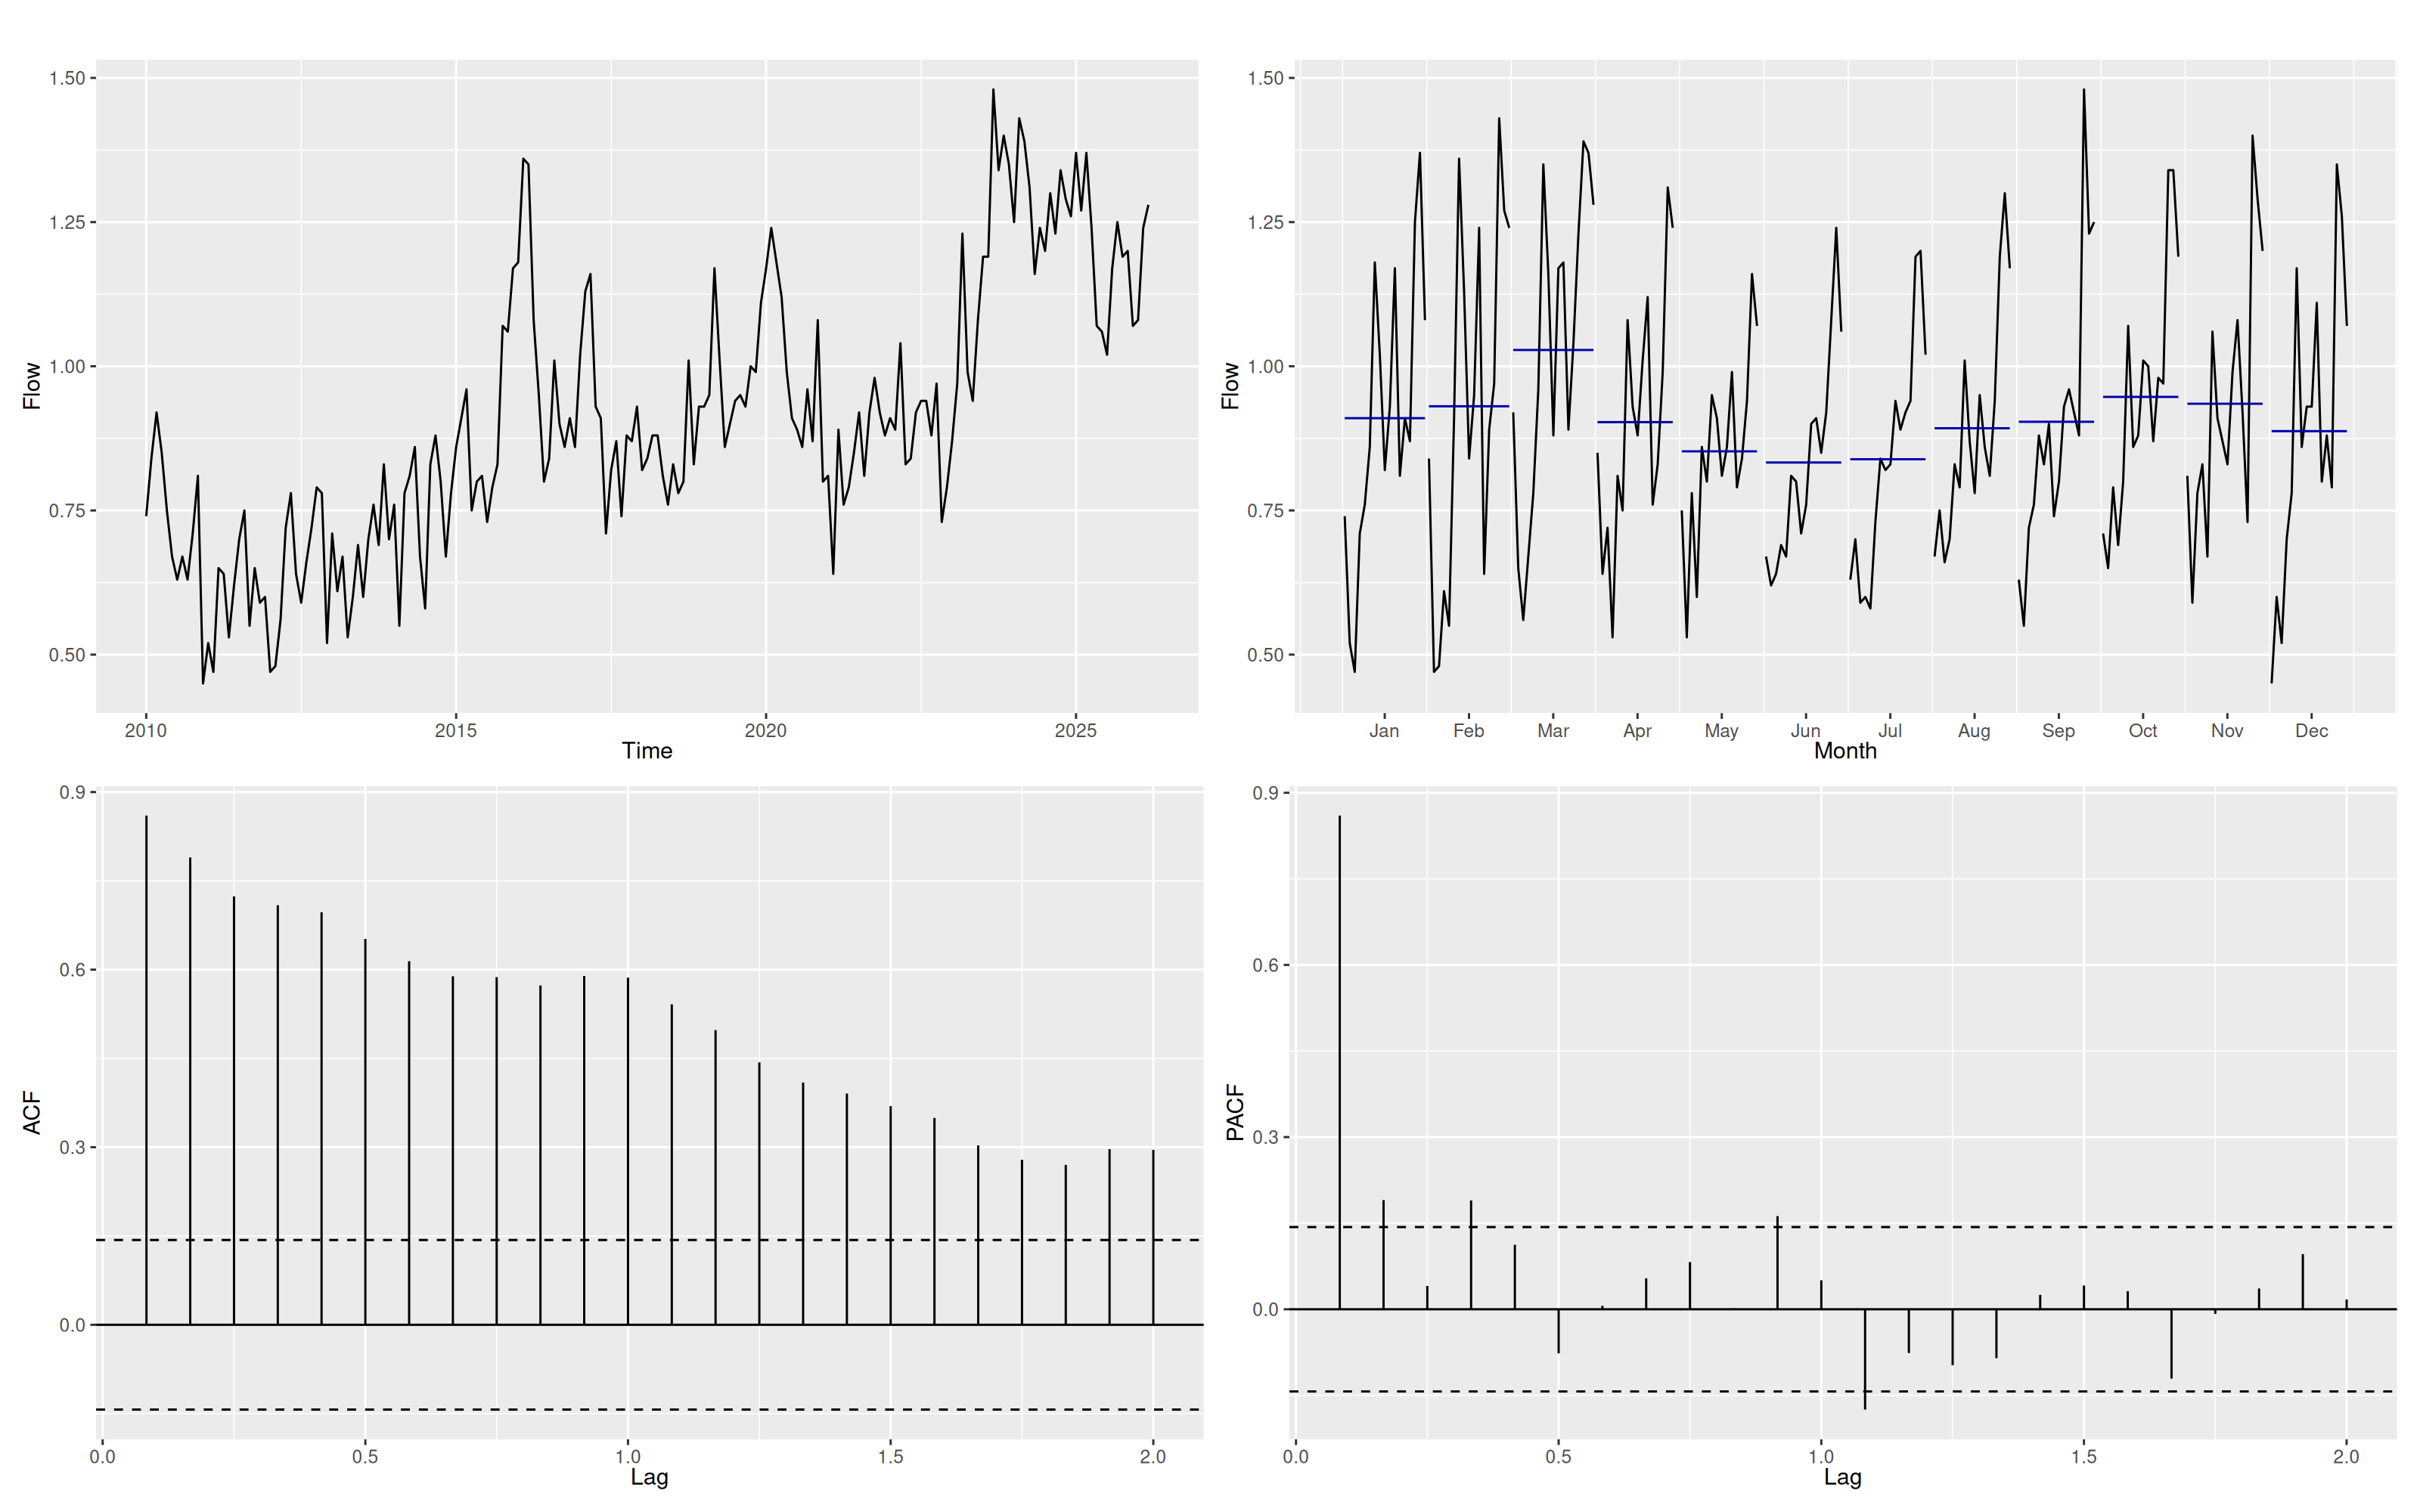

In [21]:
# Plots da serie ----------------------------------------------------------
serie <- autoplot(y, ylab = "Flow")
sub_serie <- ggsubseriesplot(y, ylab = "Flow")

bacf <- acf(y, plot = F, lag.max = 24)
bacfdf <- with(bacf, data.frame(lag, acf))[-1,]

acf_serie <- ggplot(data = bacfdf, mapping = aes(x = lag, y = acf)) +
  geom_hline(aes(yintercept = 0)) +
  geom_segment(mapping = aes(xend = lag, yend = 0)) +
  geom_hline(aes(yintercept = 2/sqrt(length(y))), linetype = 2, color = 'black') +
  geom_hline(aes(yintercept = -2/sqrt(length(y))), linetype = 2, color = 'black') +
  ylab("ACF") + xlab("Lag")

bpacf <- pacf(y, plot = F, lag.max = 24)
bpacfdf <- with(bpacf, data.frame(lag, acf))

pacf_serie <- ggplot(data = bpacfdf, mapping = aes(x = lag, y = acf)) +
  geom_hline(aes(yintercept = 0)) +
  geom_segment(mapping = aes(xend = lag, yend = 0)) +
  geom_hline(aes(yintercept = 2/sqrt(length(y))), linetype = 2, color = 'black') +
  geom_hline(aes(yintercept = -2/sqrt(length(y))), linetype = 2, color = 'black') +
  ylab("PACF") + xlab("Lag")

(serie + sub_serie) / (acf_serie + pacf_serie)

In [22]:
# Serie da amostra --------------------------------------------------------
n <- length(y)
h1 <- 6
n1 <- n-h1

y1 <- ts(y[1:n1], start = c(2010,1), frequency = 12)

In [23]:
# Variaveis harmonicas ----------------------------------------------------
t <- 1:n1 # in sample
t_hat <- (n1+1):(n1+h1) # out of sample

# deterministic seazonality
C<-cos(2*pi*t/12) # in sample 
C_hat<-cos(2*pi*t_hat/12) # out of sample

S<-sin(2*pi*t/12) # in sample
S_hat<-sin(2*pi*t_hat/12) # out of sample

nina34 <- import("db/nina34.anom.csv", HEADER = TRUE) |>
  mutate(Date = yearmonth(Date)) |>
  filter(Date >= yearmonth("2010-01"), Date < yearmonth("2026-04")) |>
  mutate(Mean = parse_number(Mean, locale = locale(decimal_mark = ","))) |>
  na.omit()

nina34_treino <- nina34$Mean[1:n1]
nina34_teste <- tail(nina34$Mean,h1)

# More than on covariate
mX<-cbind(S,C,t,nina34_treino) # in sample
mX_hat<-cbind(S_hat,C_hat,t_hat,nina34_teste) # out of sample

In [24]:
# Modelo proposto ---------------------------------------------------------
fit_gbparma <- gbparma(y = y1, ar = c(1), ma = c(1), h1 = h1, X = mX, 
                       X_hat = mX_hat, resid = 1, diag = 0)

       Estimate Std. Error z value Pr(>|z|)
alpha1  -0.1610     0.0529  3.0421   0.0023
phi1     0.6489     0.1130  5.7423   0.0000
theta1  -0.2445     0.1454  1.6819   0.0926
alpha2   5.1601     0.7513  6.8682   0.0000
delta   -0.1350     0.7351  0.1837   0.8543
beta1    0.0095     0.0179  0.5303   0.5959
beta2    0.0355     0.0179  1.9816   0.0475
beta3    0.0035     0.0004  9.9442   0.0000
beta4    0.1040     0.0189  5.4929   0.0000
[1]  
[1] Log-likelihood: 160.1689       
[1] Number of iterations in BFGS optim: 694                                
[1] AIC:      -302.3378  BIC:     -273.1621


In [25]:
# Portmanteau -------------------------------------------------------------

Box.test(fit_gbparma$resid1, lag = round(sqrt(n1)), type = "Ljung-Box", fitdf = 1)


	Box-Ljung test

data:  fit_gbparma$resid1
X-squared = 19.805, df = 13, p-value = 0.1002


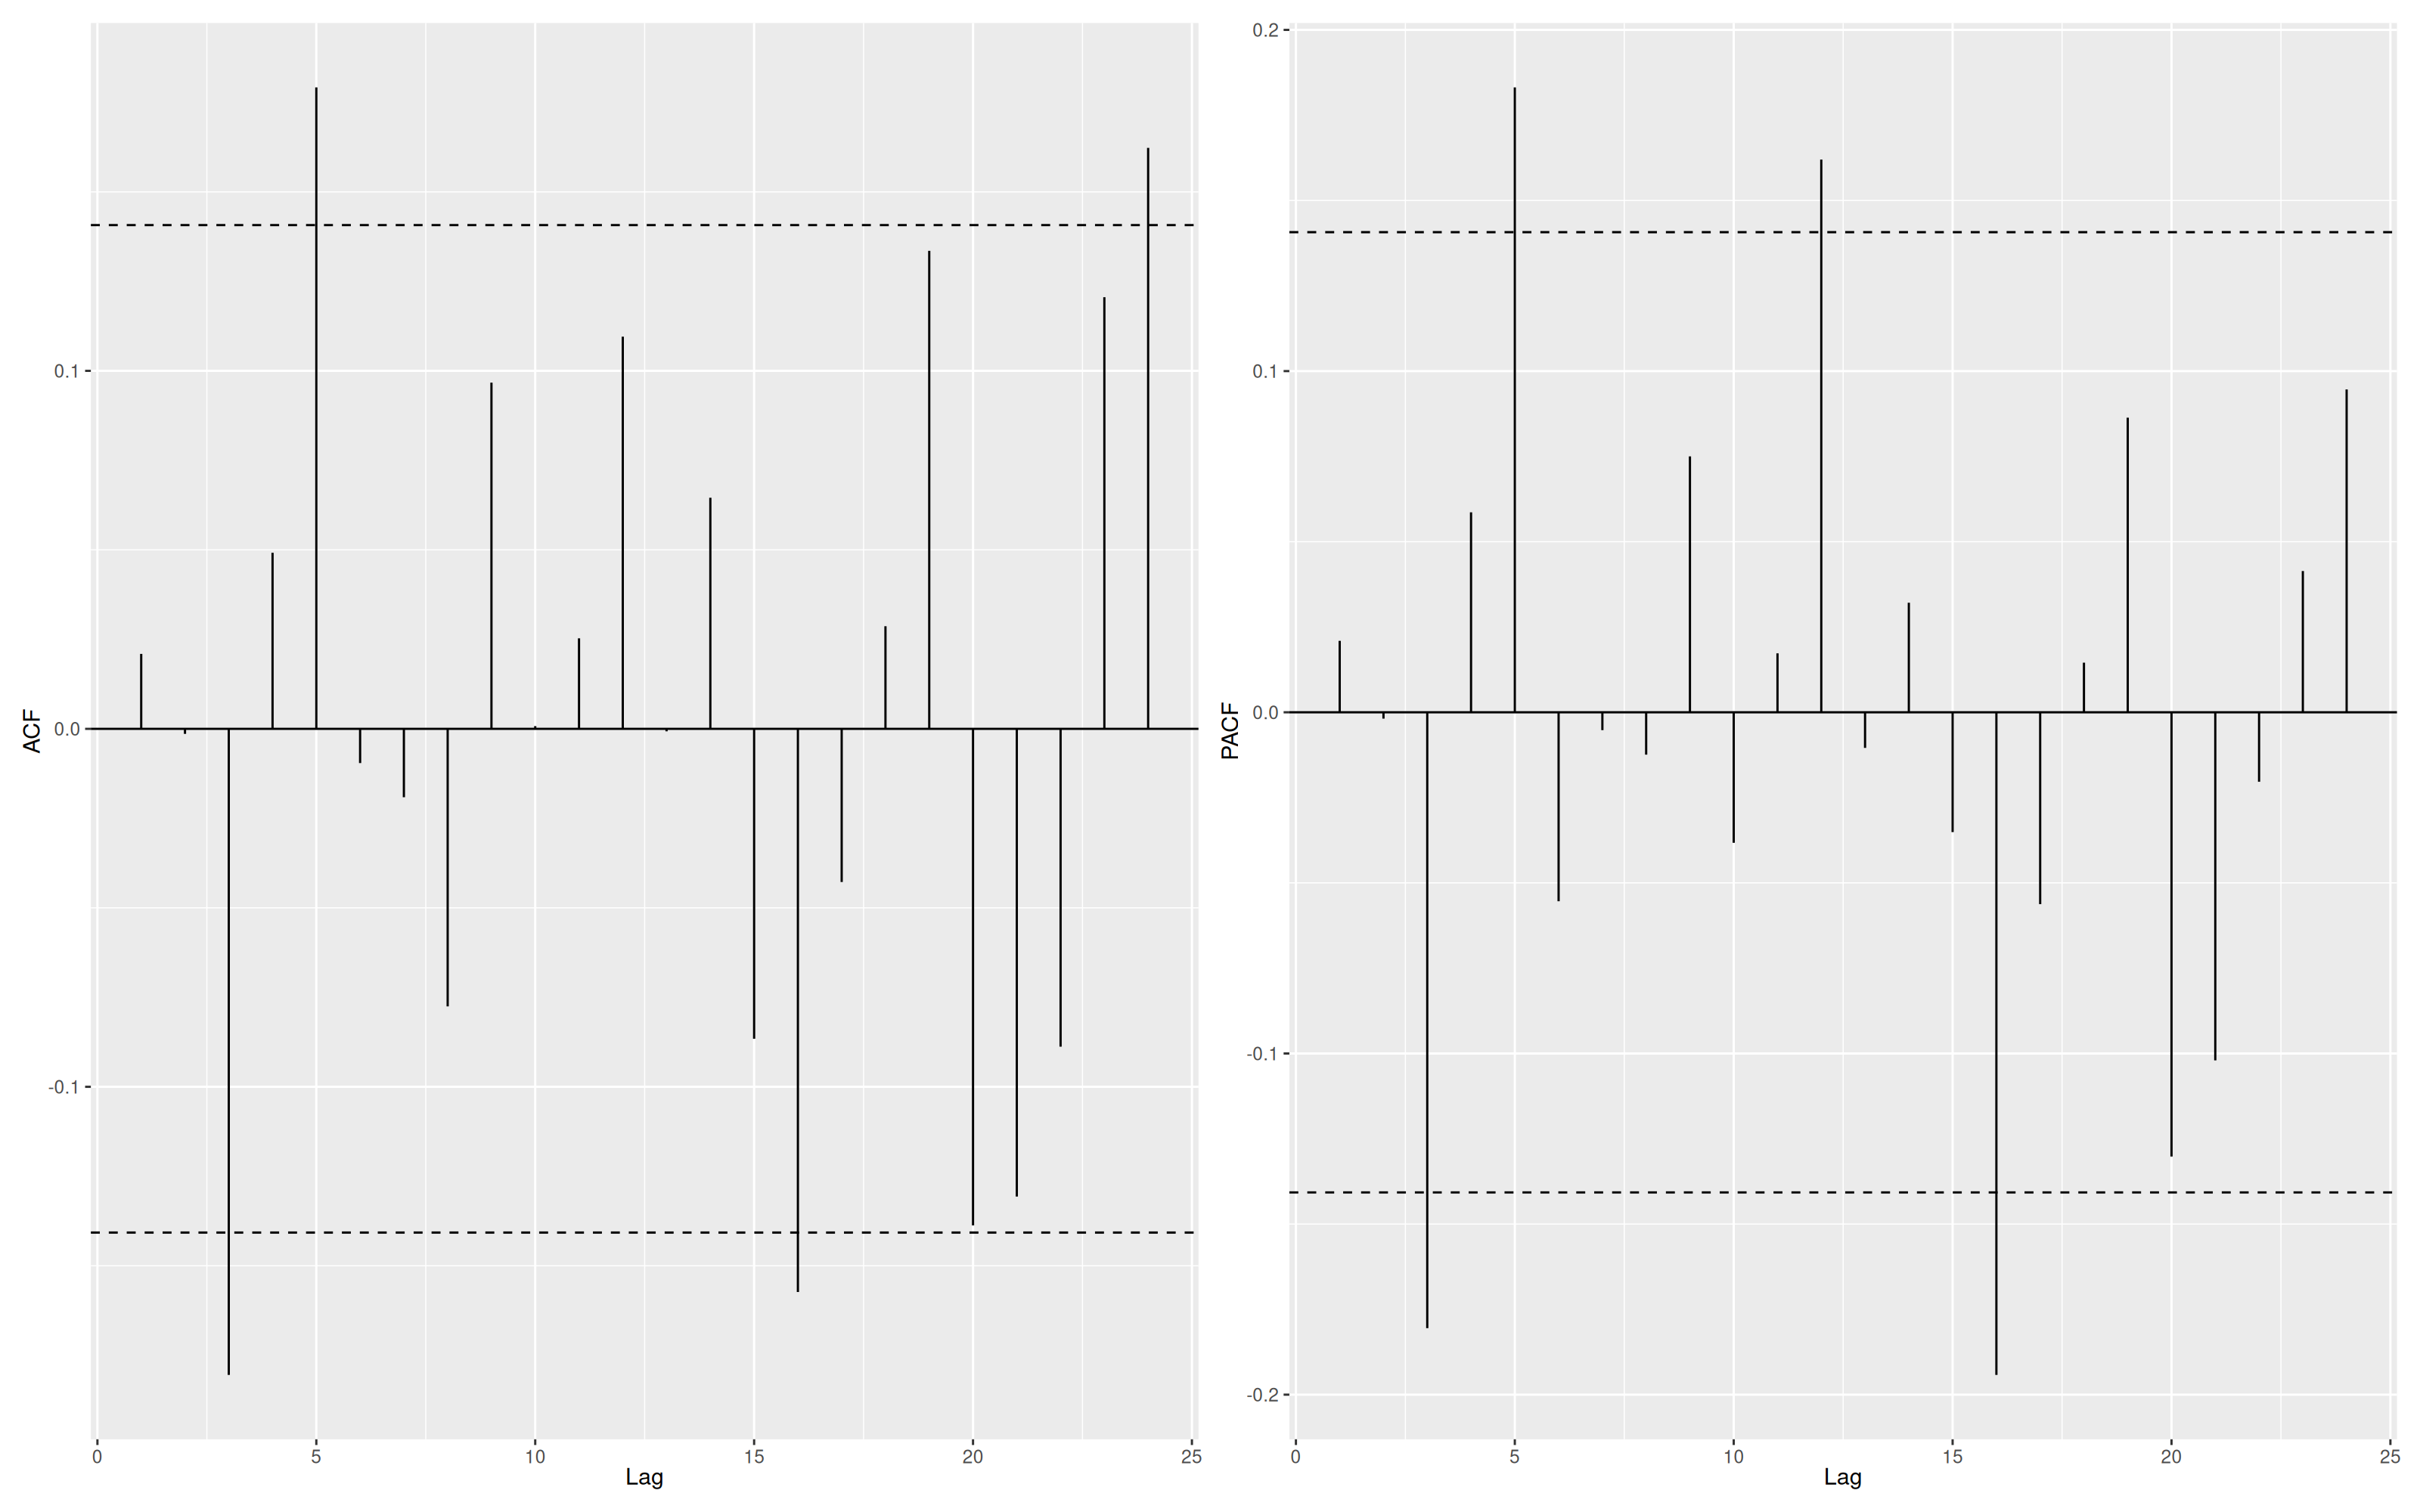

In [26]:
# Analise de diagnostico --------------------------------------------------

bacf <- acf(fit_gbparma$resid3[-1], plot = F, lag.max = 24)
bacfdf <- with(bacf, data.frame(lag, acf))[-1,]

acf_res <- ggplot(data = bacfdf, mapping = aes(x = lag, y = acf)) +
  geom_hline(aes(yintercept = 0)) +
  geom_segment(mapping = aes(xend = lag, yend = 0)) +
  geom_hline(aes(yintercept = 1.96/sqrt(n-1)), linetype = 2, color = 'black') +
  geom_hline(aes(yintercept = -1.96/sqrt(n-1)), linetype = 2, color = 'black') +
  ylab("ACF") + xlab("Lag")

bpacf <- pacf(fit_gbparma$resid3[-1], plot = F, lag.max = 24)
bpacfdf <- with(bpacf, data.frame(lag, acf))

pacf_res <- ggplot(data = bpacfdf, mapping = aes(x = lag, y = acf)) +
  geom_hline(aes(yintercept = 0)) +
  geom_segment(mapping = aes(xend = lag, yend = 0)) +
  geom_hline(aes(yintercept = 1.96/sqrt(n-1)), linetype = 2, color = 'black') +
  geom_hline(aes(yintercept = -1.96/sqrt(n-1)), linetype = 2, color = 'black') +
  ylab("PACF") + xlab("Lag")

(acf_res + pacf_res)

Don't know how to automatically pick scale for object of type <ts>. Defaulting to continuous.
Warning message:
“Removed 3 rows containing missing values or values outside the scale range (`geom_line()`).”


[1] 0.8984675

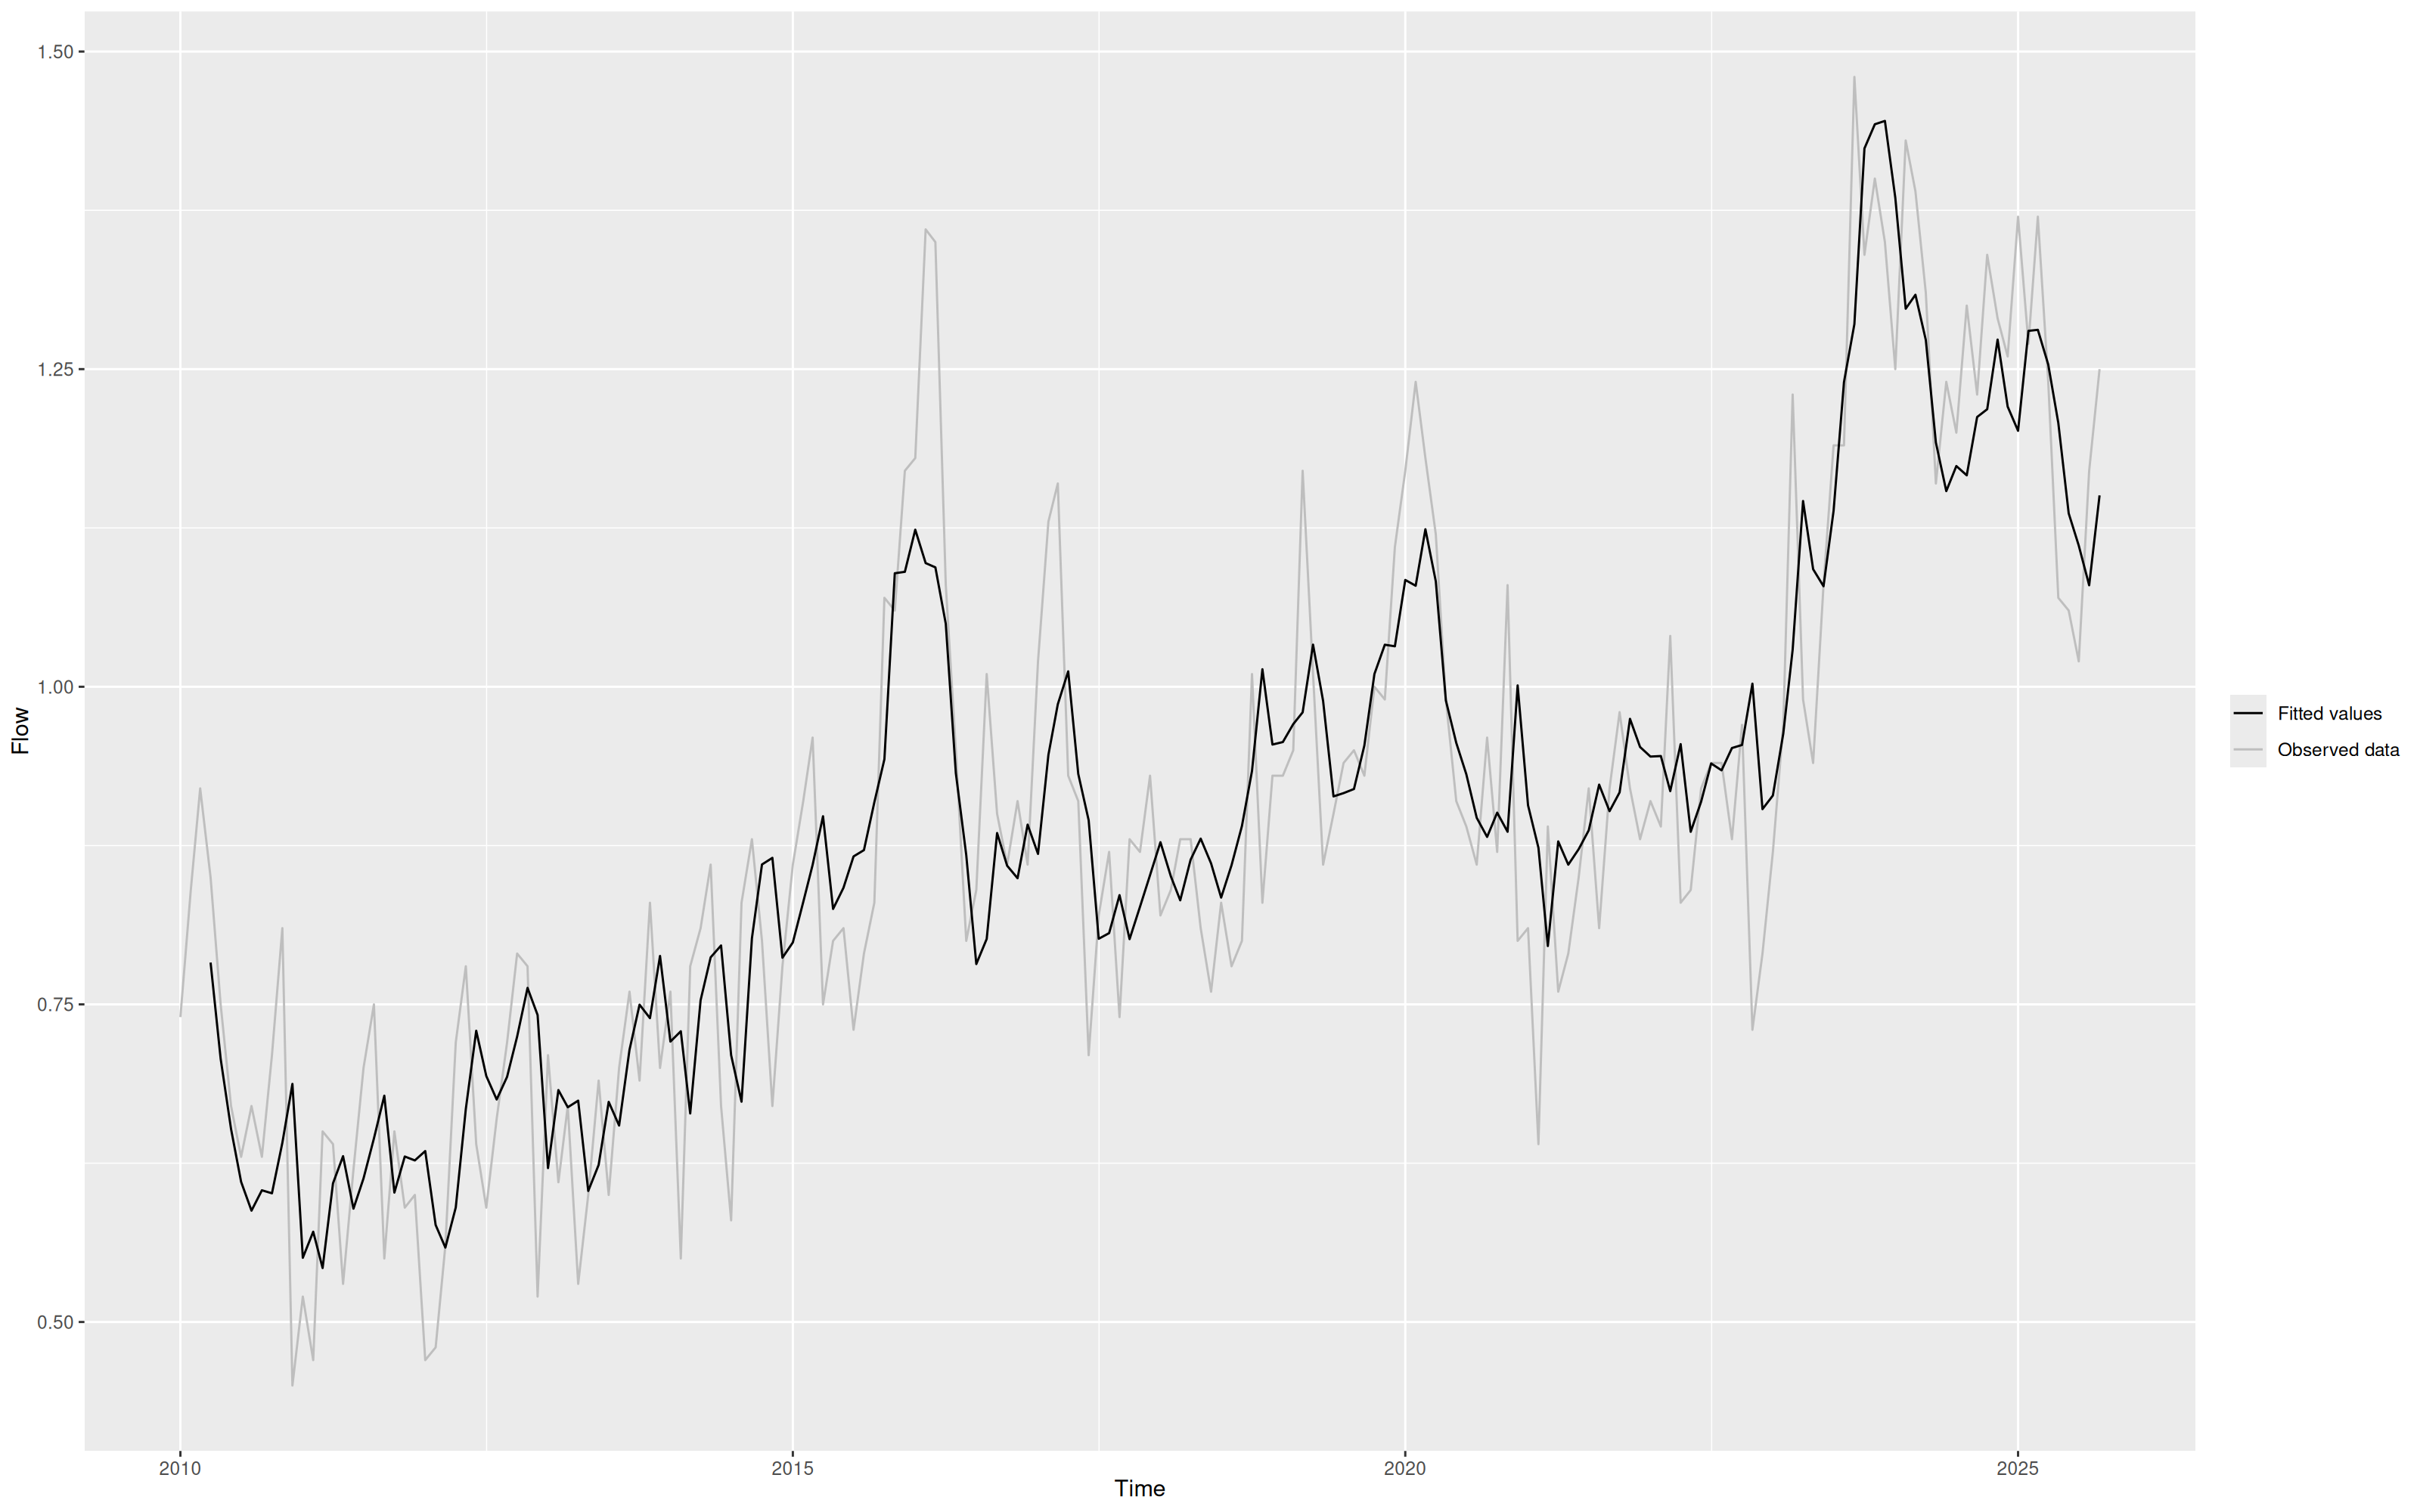

In [27]:
# Plot do ajuste ----------------------------------------------------------
b <- seq.Date(as.Date("2010/1/1"), as.Date("2025/9/1"), "month")
x1 <- data.frame(Data = b, Observado = y1,
                 GBPARMA = fit_gbparma$fitted)

ajuste <- ggplot(x1, aes(x=Data)) +
  geom_line(aes(y = Observado, colour = "Observed data")) +
  geom_line(aes(y = GBPARMA, colour = "Fitted values")) +
  ggplot2::scale_colour_manual(
    values = c('Observed data' = "gray", 'Fitted values' = "black"),
  ) +
  ggplot2::labs(colour = NULL) +
  xlab("Time") +
  ylab("Flow"); ajuste

cor(fit_gbparma$fitted[-c(1:3)],y1[-c(1:3)])

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  143.6   150.2   151.9   152.0   153.8   161.6 

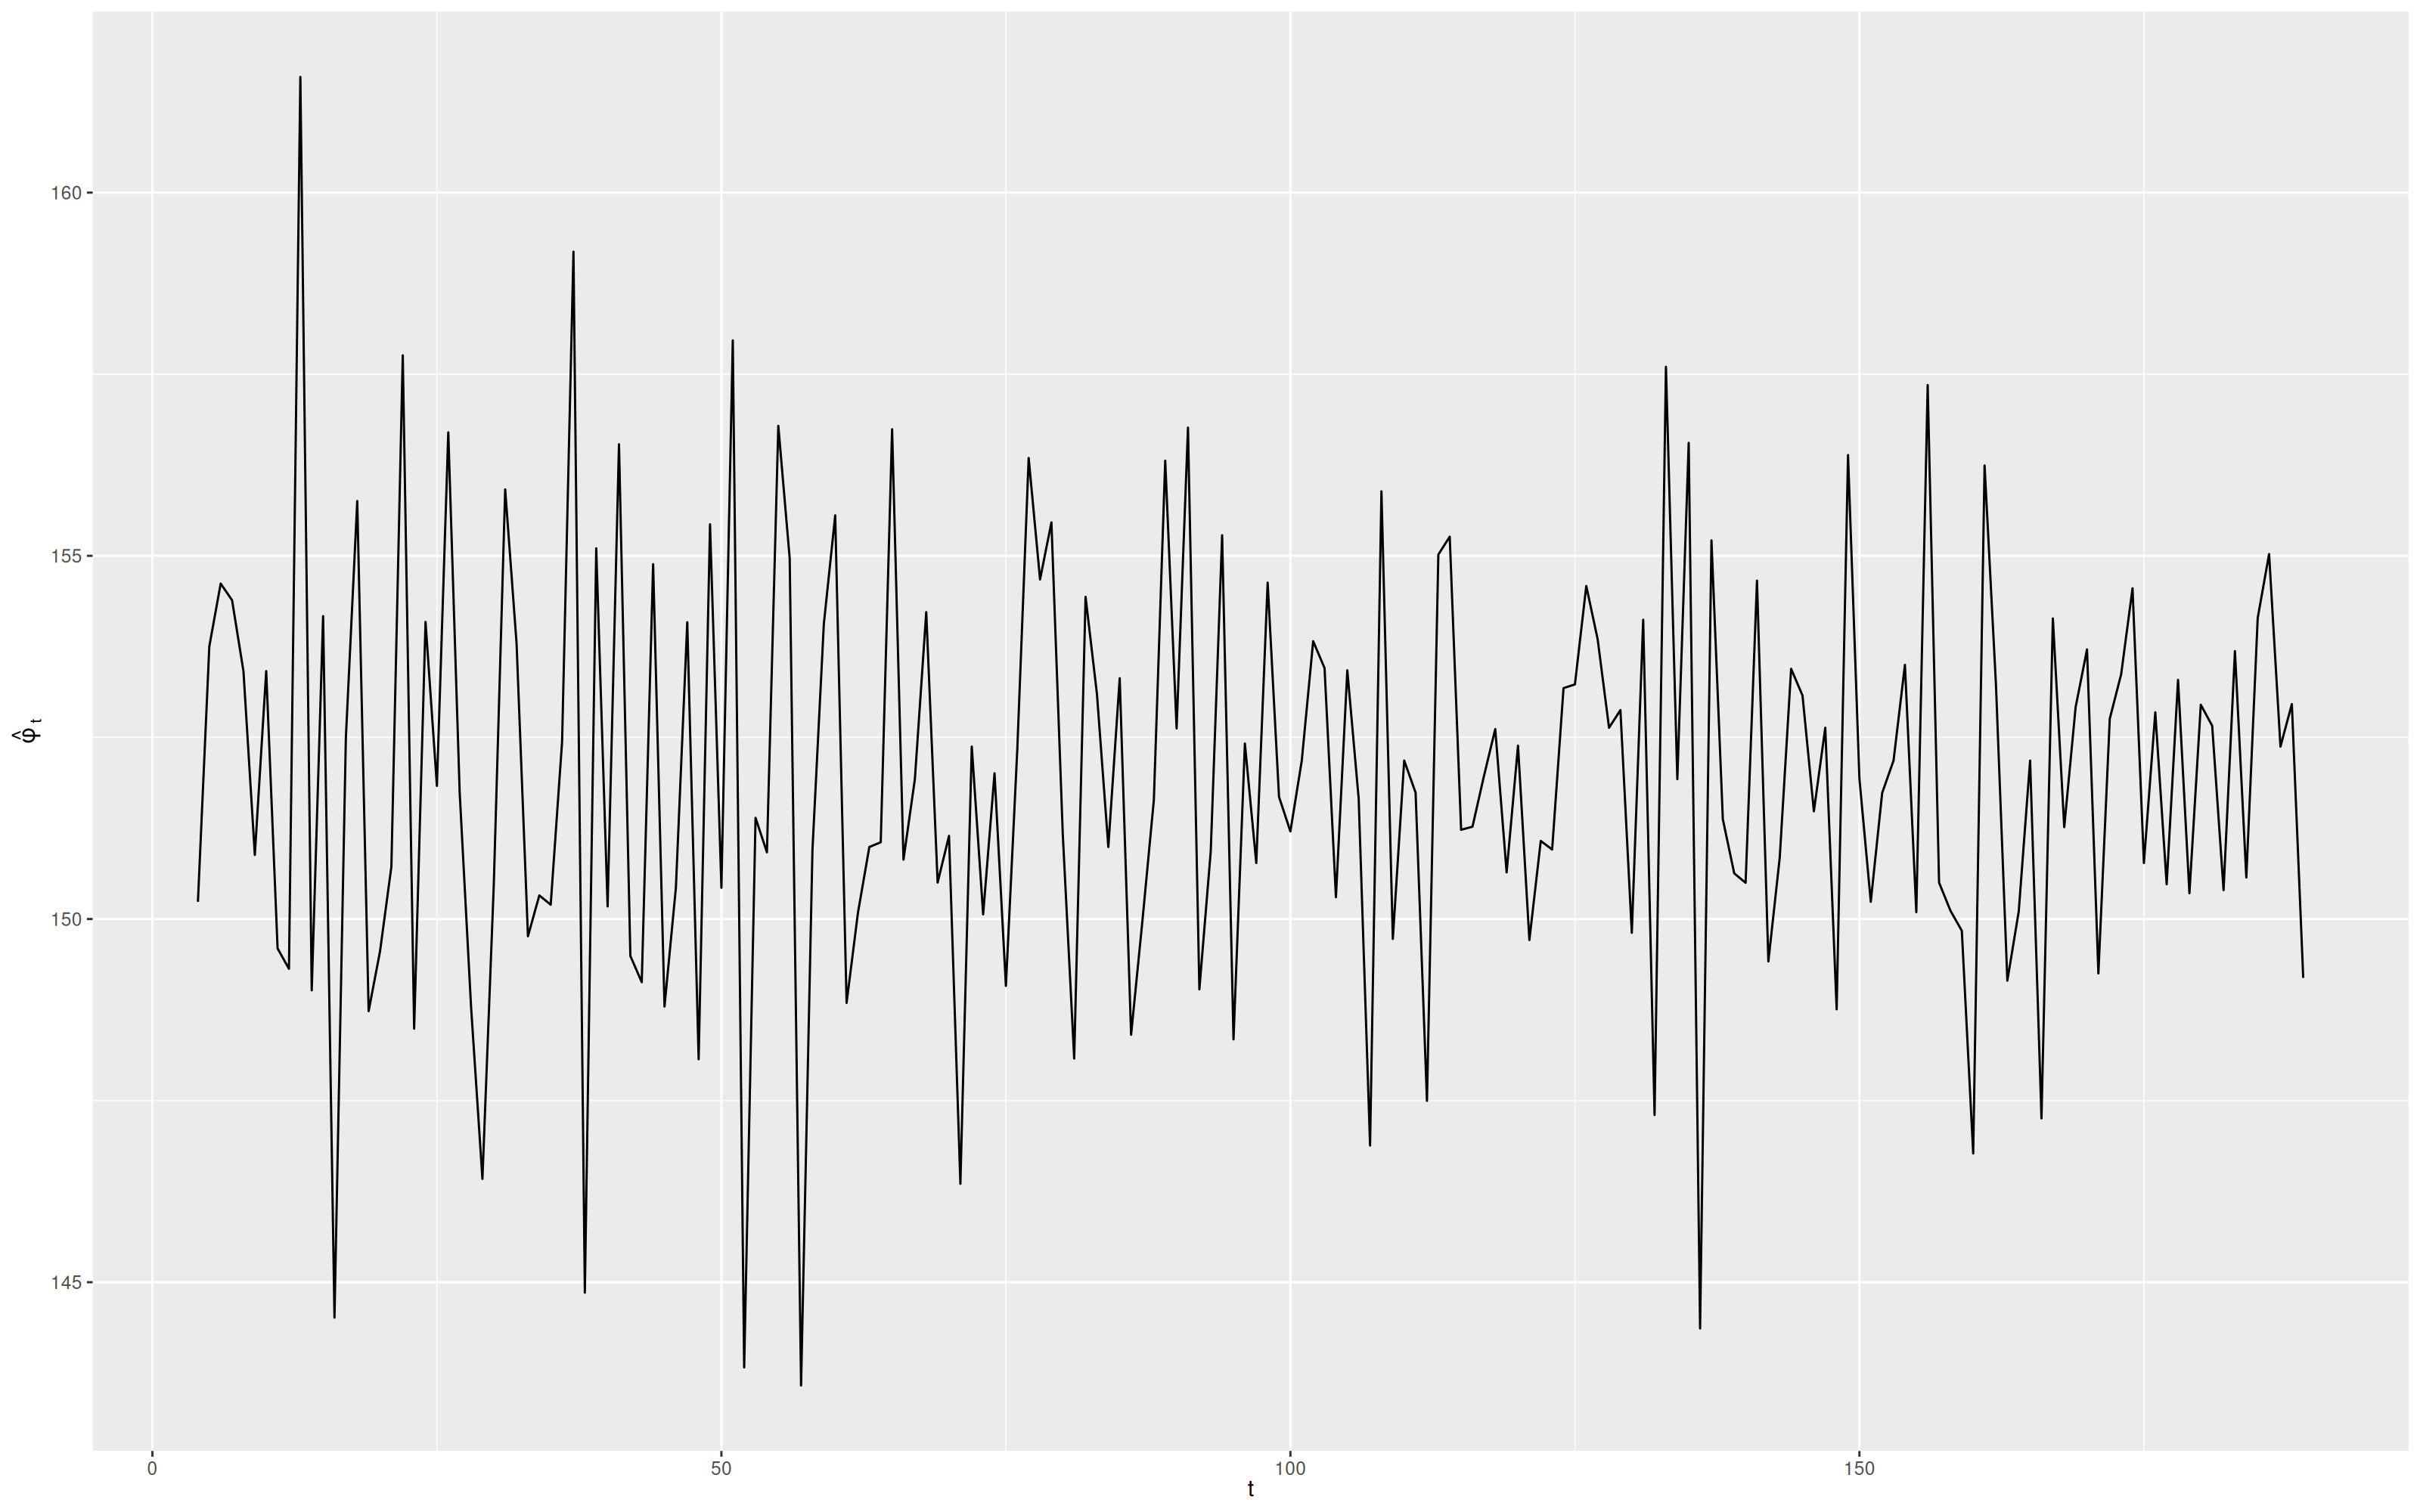

In [28]:
# plots da precisao --------------------------------------------------------
summary(fit_gbparma$fitted_prec[-c(1:3)])

b <- data.frame(y = fit_gbparma$fitted_prec[-c(1:3)],
                x = 4:(length(fit_gbparma$fitted_prec)))

ggplot(b, aes(x = x, y = y)) +
  geom_line() +
  # geom_hline(yintercept = fit_bparma$prec, linetype = "dashed") +
  ylab(expression(hat(phi)[~t])) +
  xlab("t") 

In [30]:
# Teste da RV -------------------------------------------------------------
xx <- 2*(fit_gbparma$loglik - fit_gbparma$loglik)
(1-pchisq(xx,1))
qchisq(0.95,1)

[1] 1

[1] 3.841459

In [31]:
# Critério de selecao de modelos ------------------------------------------
fit_gbparma$aic;fit_gbparma$bic

[1] -302.3378

[1] -273.1621

In [32]:
# Demais modelos ----------------------------------------------------------
SARIMA <- auto.arima(y1, ic = "aic",allowdrift = F);SARIMA
prev_sarima <- predict(SARIMA,6)

Series: y1 
ARIMA(0,1,1)(2,0,0)[12] 

Coefficients:
          ma1    sar1    sar2
      -0.3652  0.1632  0.1917
s.e.   0.0800  0.0730  0.0742

sigma^2 = 0.01194:  log likelihood = 150.24
AIC=-292.48   AICc=-292.26   BIC=-279.53

In [33]:
# medidas de acuracia das previsões ---------------------------------------

## MAE
a1 <- mae(y_true = y[n1+1], y_pred = fit_gbparma$forecast[1])
a2 <- mae(y_true = y[(n1+1):(n1+2)], y_pred = fit_gbparma$forecast[1:2])
a3 <- mae(y_true = y[(n1+1):(n1+3)], y_pred = fit_gbparma$forecast[1:3])
a4 <- mae(y_true = y[(n1+1):(n1+4)], y_pred = fit_gbparma$forecast[1:4])
a5 <- mae(y_true = y[(n1+1):(n1+5)], y_pred = fit_gbparma$forecast[1:5])
a6 <- mae(y_true = y[(n1+1):(n1+6)], y_pred = fit_gbparma$forecast[1:6])

c1 <- mae(y_true = y[n1+1], y_pred = prev_sarima$pred[1])
c2 <- mae(y_true = y[(n1+1):(n1+2)], y_pred = prev_sarima$pred[1:2])
c3 <- mae(y_true = y[(n1+1):(n1+3)], y_pred = prev_sarima$pred[1:3])
c4 <- mae(y_true = y[(n1+1):(n1+4)], y_pred = prev_sarima$pred[1:4])
c5 <- mae(y_true = y[(n1+1):(n1+5)], y_pred = prev_sarima$pred[1:5])
c6 <- mae(y_true = y[(n1+1):(n1+6)], y_pred = prev_sarima$pred[1:6])

mae1 <- data.frame(
  'h=1' = c(a1,c1),
  'h=2' = c(a2,c2),
  'h=3' = c(a3,c3),
  'h=4' = c(a4,c4),
  'h=5' = c(a5,c5),
  'h=6' = c(a6,c6)
)

rownames(mae1) <- c("Generalized BPARMA", "SARIMA");mae1
round(mae1,4)

# xtable::xtable(mae1, digits = 4)

## MAPE
a1 <- mape(y_true = y[n1+1], y_pred = fit_gbparma$forecast[1])
a2 <- mape(y_true = y[(n1+1):(n1+2)], y_pred = fit_gbparma$forecast[1:2])
a3 <- mape(y_true = y[(n1+1):(n1+3)], y_pred = fit_gbparma$forecast[1:3])
a4 <- mape(y_true = y[(n1+1):(n1+4)], y_pred = fit_gbparma$forecast[1:4])
a5 <- mape(y_true = y[(n1+1):(n1+5)], y_pred = fit_gbparma$forecast[1:5])
a6 <- mape(y_true = y[(n1+1):(n1+6)], y_pred = fit_gbparma$forecast[1:6])

c1 <- mape(y_true = y[n1+1], y_pred = prev_sarima$pred[1])
c2 <- mape(y_true = y[(n1+1):(n1+2)], y_pred = prev_sarima$pred[1:2])
c3 <- mape(y_true = y[(n1+1):(n1+3)], y_pred = prev_sarima$pred[1:3])
c4 <- mape(y_true = y[(n1+1):(n1+4)], y_pred = prev_sarima$pred[1:4])
c5 <- mape(y_true = y[(n1+1):(n1+5)], y_pred = prev_sarima$pred[1:5])
c6 <- mape(y_true = y[(n1+1):(n1+6)], y_pred = prev_sarima$pred[1:6])

mape1 <- data.frame(
  'h=1' = c(a1,c1),
  'h=2' = c(a2,c2),
  'h=3' = c(a3,c3),
  'h=4' = c(a4,c4),
  'h=5' = c(a5,c5),
  'h=6' = c(a6,c6)
)

rownames(mape1) <- c("Generalized BPARMA", "SARIMA");mape1
round(mape1,4)

# xtable::xtable(mape1, digits = 4)

## sMAPE
a1 <- smape(y_true = y[n1+1], y_pred = fit_gbparma$forecast[1])
a2 <- smape(y_true = y[(n1+1):(n1+2)], y_pred = fit_gbparma$forecast[1:2])
a3 <- smape(y_true = y[(n1+1):(n1+3)], y_pred = fit_gbparma$forecast[1:3])
a4 <- smape(y_true = y[(n1+1):(n1+4)], y_pred = fit_gbparma$forecast[1:4])
a5 <- smape(y_true = y[(n1+1):(n1+5)], y_pred = fit_gbparma$forecast[1:5])
a6 <- smape(y_true = y[(n1+1):(n1+6)], y_pred = fit_gbparma$forecast[1:6])

c1 <- smape(y_true = y[n1+1], y_pred = prev_sarima$pred[1])
c2 <- smape(y_true = y[(n1+1):(n1+2)], y_pred = prev_sarima$pred[1:2])
c3 <- smape(y_true = y[(n1+1):(n1+3)], y_pred = prev_sarima$pred[1:3])
c4 <- smape(y_true = y[(n1+1):(n1+4)], y_pred = prev_sarima$pred[1:4])
c5 <- smape(y_true = y[(n1+1):(n1+5)], y_pred = prev_sarima$pred[1:5])
c6 <- smape(y_true = y[(n1+1):(n1+6)], y_pred = prev_sarima$pred[1:6])

smape1 <- data.frame(
  'h=1' = c(a1,c1),
  'h=2' = c(a2,c2),
  'h=3' = c(a3,c3),
  'h=4' = c(a4,c4),
  'h=5' = c(a5,c5),
  'h=6' = c(a6,c6)
)

rownames(smape1) <- c("Generalized BPARMA", "SARIMA");smape1
round(smape1,4)

# xtable::xtable(smape1, digits = 4)

,h.1,h.2,h.3,h.4,h.5,h.6
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Generalized BPARMA,0.02706569,0.01572661,0.05926680,0.08123022,0.06827301,0.05821080
SARIMA,0.02477927,0.02145040,0.05884699,0.07474069,0.06367082,0.06151557


,h.1,h.2,h.3,h.4,h.5,h.6
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Generalized BPARMA,0.0271,0.0157,0.0593,0.0812,0.0683,0.0582
SARIMA,0.0248,0.0215,0.0588,0.0747,0.0637,0.0615


,h.1,h.2,h.3,h.4,h.5,h.6
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Generalized BPARMA,2.274428,1.320028,5.439120,7.484908,6.253155,5.313823
SARIMA,2.082292,1.796210,5.360718,6.854376,5.796264,5.490889


,h.1,h.2,h.3,h.4,h.5,h.6
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Generalized BPARMA,2.2744,1.3200,5.4391,7.4849,6.2532,5.3138
SARIMA,2.0823,1.7962,5.3607,6.8544,5.7963,5.4909


,h.1,h.2,h.3,h.4,h.5,h.6
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Generalized BPARMA,2.248854,1.306907,5.138549,7.042313,5.897332,5.017623
SARIMA,2.060836,1.779823,5.105086,6.510655,5.523752,5.277154


,h.1,h.2,h.3,h.4,h.5,h.6
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Generalized BPARMA,2.2489,1.3069,5.1385,7.0423,5.8973,5.0176
SARIMA,2.0608,1.7798,5.1051,6.5107,5.5238,5.2772
